In [1]:
rm(list = ls())
gc()

library(Seurat)
library(dplyr)

library("SymSim")


setwd('/mnt/data00/Minghui/project_NMF/10_simlate_count/')

cluster_cols <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72",
  "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", "#E78AC3",
  "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D",
  "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000",
  "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,634144,33.9,1390690,74.3,1026282,54.9
Vcells,1176746,9.0,8388608,64.0,1815604,13.9


Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: plyr

------------------------------------------------------------------------------

You have loaded plyr after dplyr - this is likely to cause problems.
If you need functions from both plyr and dplyr, please load plyr first, then dplyr:
library(plyr); library(dplyr)

------------------------------------------------------------------------------


Attaching package: ‘plyr’


The following objects are masked from ‘package:dplyr’:

    arrange, count, desc, failwith, id, mutate, rename, summarise,
    summarize


Loading required package: ggplot2

Loading required package: Rtsne

Loading r

## Generate count Matrix

##### 500 cells 7000 genes

Time difference of 32.0546 mins

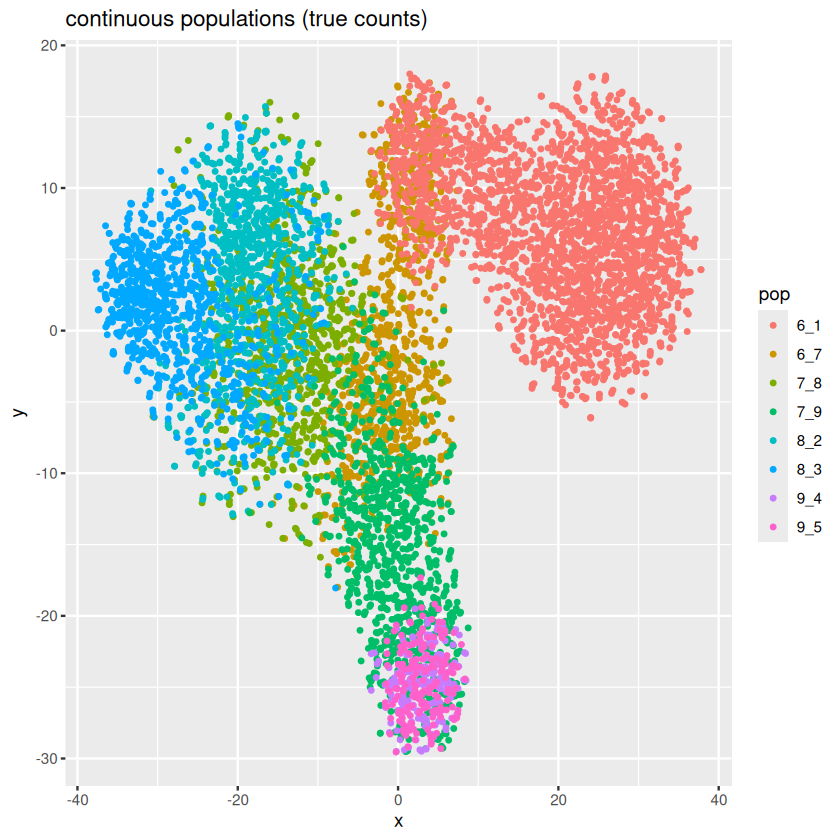

In [12]:
start_time <- Sys.time()

true_counts_res <- SimulateTrueCounts(ncells_total=8000, 
                                      ngenes=7000, 
                                      nevf=20, 
                                      evf_type="continuous", 
                                      n_de_evf=12, vary="s",
                                      Sigma=0.4, phyla=Phyla5(), randseed=1)
tsne_true_counts <- PlotTsne(meta=true_counts_res[[3]], data=log2(true_counts_res[[1]]+1), evf_type="continuous", n_pc=20, label='pop', saving = F, plotname="continuous populations (true counts)")
tsne_true_counts[[2]]

end_time <- Sys.time()
end_time - start_time  

In [13]:
saveRDS(true_counts_res,'./01_true_counts_res.rds')

In [2]:
true_counts_res <-readRDS('./01_true_counts_res.rds')

In [3]:
true_counts_res %>% str()

List of 5
 $ counts        : int [1:7000, 1:8000] 14 2590 1 52 33 0 137 27 203 7 ...
 $ gene_effects  :List of 3
  ..$ : num [1:7000, 1:20] 0 0.0741 0 0 0 ...
  ..$ : num [1:7000, 1:20] 0 0 0 0 0 ...
  ..$ : num [1:7000, 1:20] 1.01 2.05 0 1.07 0 ...
 $ cell_meta     :'data.frame':	8000 obs. of  63 variables:
  ..$ cellid       : chr [1:8000] "cell_1" "cell_2" "cell_3" "cell_4" ...
  ..$ pop          : chr [1:8000] "6_7" "6_7" "6_7" "6_7" ...
  ..$ depth        : num [1:8000] 0 0.00105 0.0021 0.00315 0.0042 ...
  ..$ kon_nonDE_1  : num [1:8000] 1.309 1.549 0.938 0.657 0.837 ...
  ..$ kon_nonDE_2  : num [1:8000] 1.247 1.661 0.883 0.963 0.89 ...
  ..$ kon_nonDE_3  : num [1:8000] 0.96 1.454 0.638 0.118 1.195 ...
  ..$ kon_nonDE_4  : num [1:8000] 1.118 0.681 1.342 0.907 1.122 ...
  ..$ kon_nonDE_5  : num [1:8000] 0.887 1.821 0.691 0.413 0.385 ...
  ..$ kon_nonDE_6  : num [1:8000] 1.773 1.259 1.542 0.546 0.967 ...
  ..$ kon_nonDE_7  : num [1:8000] 1.138 0.996 1.141 1.251 1.367 ...
  ..$ kon_

In [4]:
count1 <- true_counts_res$counts

rownames(count1 ) <- paste0('gene',1:nrow(count1))

colnames(count1) <- paste0('cell',1:ncol(count1))

count1[1:5,1:5]

,cell1,cell2,cell3,cell4,cell5
gene1,14,1,7,12,6
gene2,2590,2900,2134,3068,1535
gene3,1,16,3,4,1
gene4,52,86,41,76,18
gene5,33,14,38,15,45


In [5]:
saveRDS(count1 ,'./02_count1.rds')

### trajectory 1

In [6]:
count1[3500:7000,] <- 1e-6 #trajectory 1

pca_res <- stats::prcomp(t(count1),center = T)

pca_df <- as.data.frame(pca_res$x[,1:2] )

pca_df$cell <- rownames(pca_df)

Performing PCA
Consider setting partial_pca=TRUE for large matrices
Read the 8000 x 50 data matrix successfully!
OpenMP is working. 1 threads.
Using no_dims = 2, perplexity = 30.000000, and theta = 0.500000
Computing input similarities...
Building tree...
Done in 0.54 seconds (sparsity = 0.014850)!
Learning embedding...
Iteration 50: error is 95.081151 (50 iterations in 0.54 seconds)
Iteration 100: error is 75.961492 (50 iterations in 0.46 seconds)
Iteration 150: error is 71.474102 (50 iterations in 0.43 seconds)
Iteration 200: error is 69.815092 (50 iterations in 0.46 seconds)
Iteration 250: error is 68.880073 (50 iterations in 0.43 seconds)
Iteration 300: error is 2.435909 (50 iterations in 0.45 seconds)
Iteration 350: error is 2.064186 (50 iterations in 0.42 seconds)
Iteration 400: error is 1.840679 (50 iterations in 0.42 seconds)
Iteration 450: error is 1.694290 (50 iterations in 0.45 seconds)
Iteration 500: error is 1.592806 (50 iterations in 0.42 seconds)
Fitting performed in 4.4

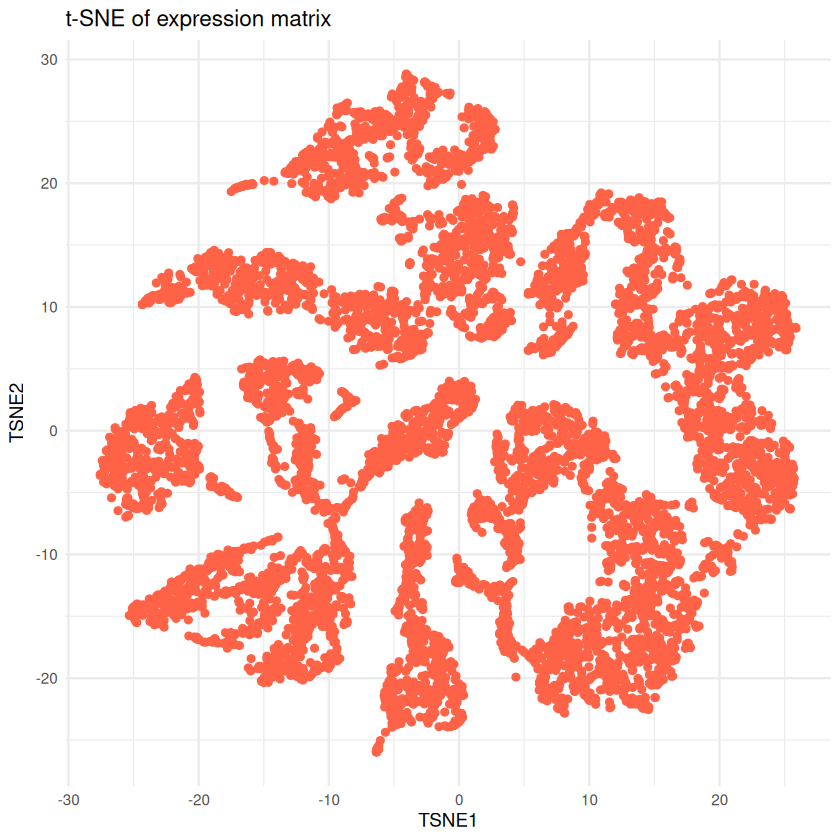

In [7]:
tsne_out <- Rtsne(t(count1), dims = 2, perplexity = 30, verbose = TRUE, max_iter = 500)

tsne_df <- data.frame(
  TSNE1 = tsne_out$Y[,1],
  TSNE2 = tsne_out$Y[,2],
  cell = colnames(count1)
)

ggplot(tsne_df, aes(x = TSNE1, y = TSNE2)) +
  geom_point(color = "tomato") +
  theme_minimal() +
  labs(title = "t-SNE of expression matrix")


Warning message:
“Removed 8000 rows containing missing values or values outside the scale
range (`geom_text()`).”


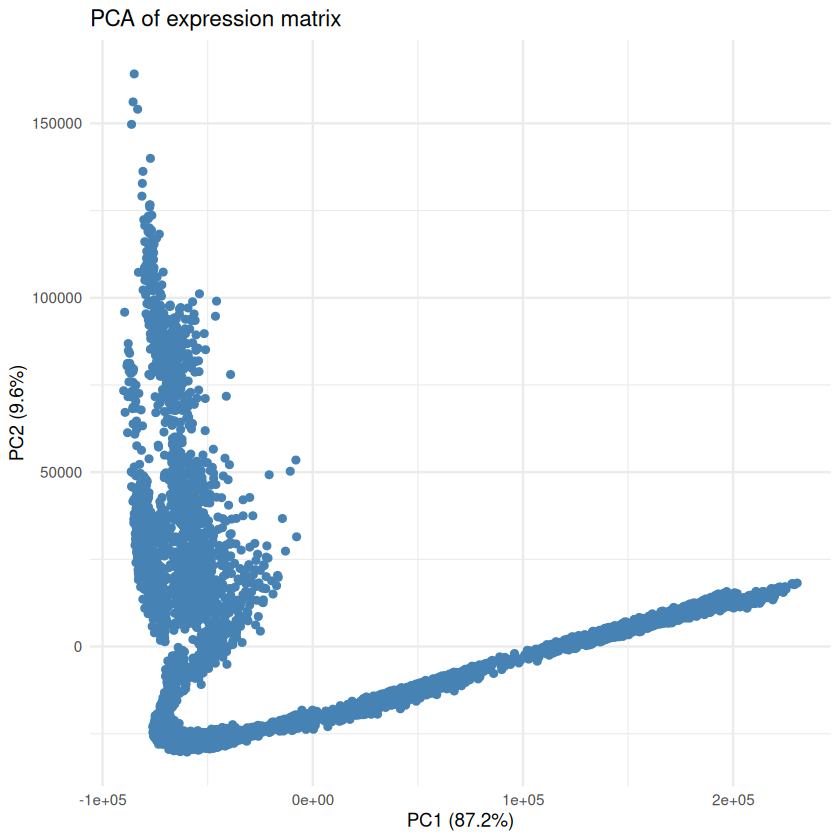

In [8]:
library(ggplot2)

ggplot(pca_df, aes(x = PC1, y = PC2, label = NA)) +
  geom_point(color = "steelblue") +
  geom_text(size = 3, vjust = -0.5) +
  theme_minimal() +
  labs(title = "PCA of expression matrix",
       x = paste0("PC1 (", round(summary(pca_res)$importance[2,1]*100, 1), "%)"),
       y = paste0("PC2 (", round(summary(pca_res)$importance[2,2]*100, 1), "%)"))


In [9]:
head(tsne_df)

,TSNE1,TSNE2,cell
,<dbl>,<dbl>,<chr>
1,20.31246,11.773291,cell1
2,22.05549,6.007832,cell2
3,20.40134,7.640212,cell3
4,19.76625,9.037359,cell4
5,20.50615,7.543847,cell5
6,20.25888,7.713086,cell6


### trajectory 2

Performing PCA
Consider setting partial_pca=TRUE for large matrices
Read the 8000 x 50 data matrix successfully!
OpenMP is working. 1 threads.
Using no_dims = 2, perplexity = 30.000000, and theta = 0.500000
Computing input similarities...
Building tree...
Done in 0.59 seconds (sparsity = 0.014503)!
Learning embedding...
Iteration 50: error is 95.195956 (50 iterations in 0.65 seconds)
Iteration 100: error is 75.880450 (50 iterations in 0.53 seconds)
Iteration 150: error is 70.034115 (50 iterations in 0.43 seconds)
Iteration 200: error is 67.910856 (50 iterations in 0.46 seconds)
Iteration 250: error is 66.799223 (50 iterations in 0.43 seconds)
Iteration 300: error is 2.286911 (50 iterations in 0.43 seconds)
Iteration 350: error is 1.919860 (50 iterations in 0.43 seconds)
Iteration 400: error is 1.698046 (50 iterations in 0.43 seconds)
Iteration 450: error is 1.553903 (50 iterations in 0.45 seconds)
Iteration 500: error is 1.453136 (50 iterations in 0.43 seconds)
Fitting performed in 4.6

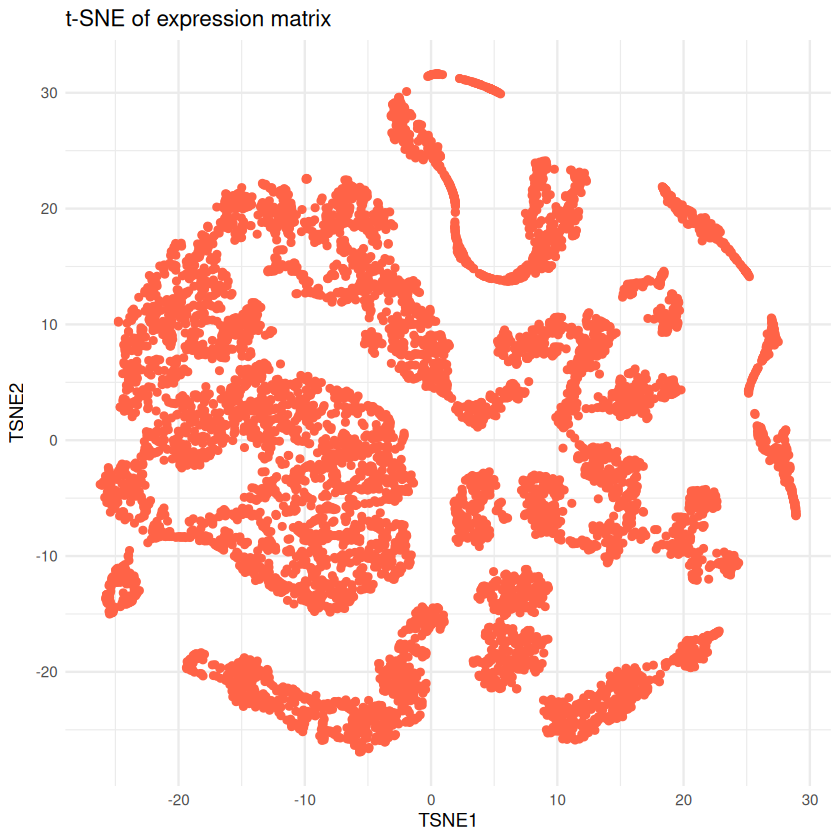

In [10]:
count2 <- true_counts_res$counts

rownames(count2 ) <- paste0('gene',1:nrow(count2))

colnames(count2) <- paste0('pcell',1:ncol(count2))

count2[1:3500,] <- 1e-6



tsne_out <- Rtsne(t(count2), dims = 2, perplexity = 30, verbose = TRUE, max_iter = 500)

tsne_df <- data.frame(
  TSNE1 = tsne_out$Y[,1],
  TSNE2 = tsne_out$Y[,2],
  cell = colnames(count2)
)

ggplot(tsne_df, aes(x = TSNE1, y = TSNE2)) +
  geom_point(color = "tomato") +
  theme_minimal() +
  labs(title = "t-SNE of expression matrix")



In [11]:
saveRDS(count2 ,'./02_count2.rds')

In [12]:
count_mat <- cbind(count1, count2)

Warning message:
“Removed 16000 rows containing missing values or values outside the scale
range (`geom_text()`).”


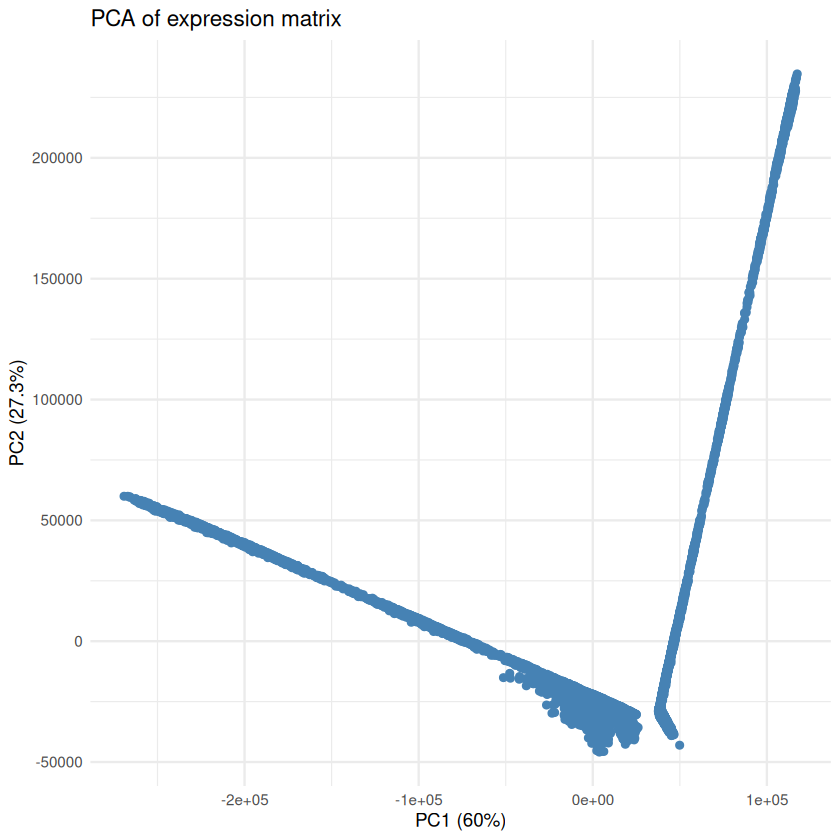

In [13]:
pca_res <- stats::prcomp(t(count_mat),center = T)

pca_df <- as.data.frame(pca_res$x[,1:2] )

pca_df$cell <- rownames(pca_df)

library(ggplot2)

ggplot(pca_df, aes(x = PC1, y = PC2, label = NA)) +
  geom_point(color = "steelblue") +
  geom_text(size = 3, vjust = -0.5) +
  theme_minimal() +
  labs(title = "PCA of expression matrix",
       x = paste0("PC1 (", round(summary(pca_res)$importance[2,1]*100, 1), "%)"),
       y = paste0("PC2 (", round(summary(pca_res)$importance[2,2]*100, 1), "%)"))


### trajectory 3

In [14]:
count3 <- count1+count2

In [15]:
colnames(count3) <- paste0('tcell',1:ncol(count2))

In [16]:
head(colnames(count3))

[1] "tcell1" "tcell2" "tcell3" "tcell4" "tcell5" "tcell6"

In [17]:
dim(count1)

dim(count2)

dim(count3)



[1] 7000 8000

[1] 7000 8000

[1] 7000 8000

In [18]:
saveRDS(count3 ,'./02_count3.rds')

### merge

In [19]:
count_mat <- cbind(cbind(count1, count2),count3)

In [20]:
saveRDS(count_mat ,'./02_count_mat.rds')

In [21]:
dim(count_mat)

[1]  7000 24000

Warning message:
“Removed 24000 rows containing missing values or values outside the scale
range (`geom_text()`).”


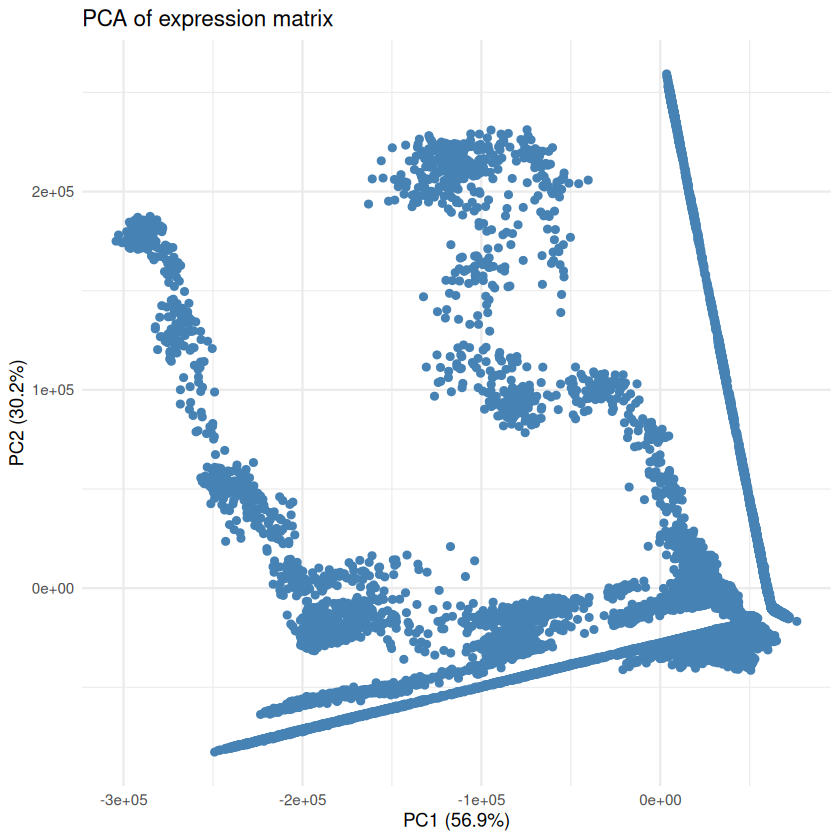

In [22]:
pca_res <- stats::prcomp(t(count_mat),center = T)

pca_df <- as.data.frame(pca_res$x[,1:2] )

pca_df$cell <- rownames(pca_df)

library(ggplot2)

ggplot(pca_df, aes(x = PC1, y = PC2, label = NA)) +
  geom_point(color = "steelblue") +
  geom_text(size = 3, vjust = -0.5) +
  theme_minimal() +
  labs(title = "PCA of expression matrix",
       x = paste0("PC1 (", round(summary(pca_res)$importance[2,1]*100, 1), "%)"),
       y = paste0("PC2 (", round(summary(pca_res)$importance[2,2]*100, 1), "%)"))


In [23]:


seurat_obj <- CreateSeuratObject(counts = count_mat)

dim(count_mat)

count_mat

seurat_obj <- NormalizeData(seurat_obj) %>%

    FindVariableFeatures( selection.method = "vst", nfeatures = 3000)%>%

    ScaleData()

seurat_obj <- RunPCA(seurat_obj, npcs = 50, verbose = FALSE)

[1]  7000 24000

,cell1,cell2,cell3,cell4,cell5,cell6,cell7,cell8,cell9,cell10,⋯,tcell7991,tcell7992,tcell7993,tcell7994,tcell7995,tcell7996,tcell7997,tcell7998,tcell7999,tcell8000
gene1,14,1,7,12,6,2,0,1,8,1,⋯,7.000001,6.000001,2.000001,3.000001,11.000001,14.000001,11.000001,11.000001,7.000001,8.000001
gene2,2590,2900,2134,3068,1535,2411,1557,1573,2571,2114,⋯,4381.000001,2869.000001,2996.000001,3842.000001,3087.000001,3119.000001,2919.000001,2625.000001,2776.000001,3577.000001
gene3,1,16,3,4,1,3,1,2,6,0,⋯,0.000001,1.000001,0.000001,10.000001,0.000001,0.000001,0.000001,4.000001,2.000001,0.000001
gene4,52,86,41,76,18,58,66,18,24,44,⋯,71.000001,50.000001,123.000001,90.000001,8.000001,5.000001,30.000001,74.000001,54.000001,30.000001
gene5,33,14,38,15,45,31,22,29,41,4,⋯,1.000001,14.000001,2.000001,2.000001,11.000001,5.000001,5.000001,4.000001,6.000001,15.000001
gene6,0,0,0,0,0,0,0,0,0,0,⋯,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001
gene7,137,124,91,78,85,33,153,141,64,78,⋯,79.000001,47.000001,89.000001,4.000001,87.000001,32.000001,36.000001,41.000001,29.000001,48.000001
gene8,27,3,28,9,5,45,69,17,11,20,⋯,10.000001,65.000001,24.000001,34.000001,26.000001,93.000001,8.000001,34.000001,6.000001,38.000001
gene9,203,181,213,192,191,185,160,204,181,155,⋯,382.000001,345.000001,368.000001,306.000001,411.000001,381.000001,276.000001,372.000001,428.000001,448.000001
gene10,7,127,17,133,115,23,76,21,11,49,⋯,43.000001,219.000001,336.000001,84.000001,198.000001,83.000001,92.000001,45.000001,121.000001,196.000001


Warning message:
“The `slot` argument of `SetAssayData()` is deprecated as of SeuratObject
5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at
  <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject
5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at
  <https://github.com/satijalab/seurat/issues>.”
Centering and scaling data matrix



Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject
5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at
  <https://github.com/satijalab/seurat/issues>.”


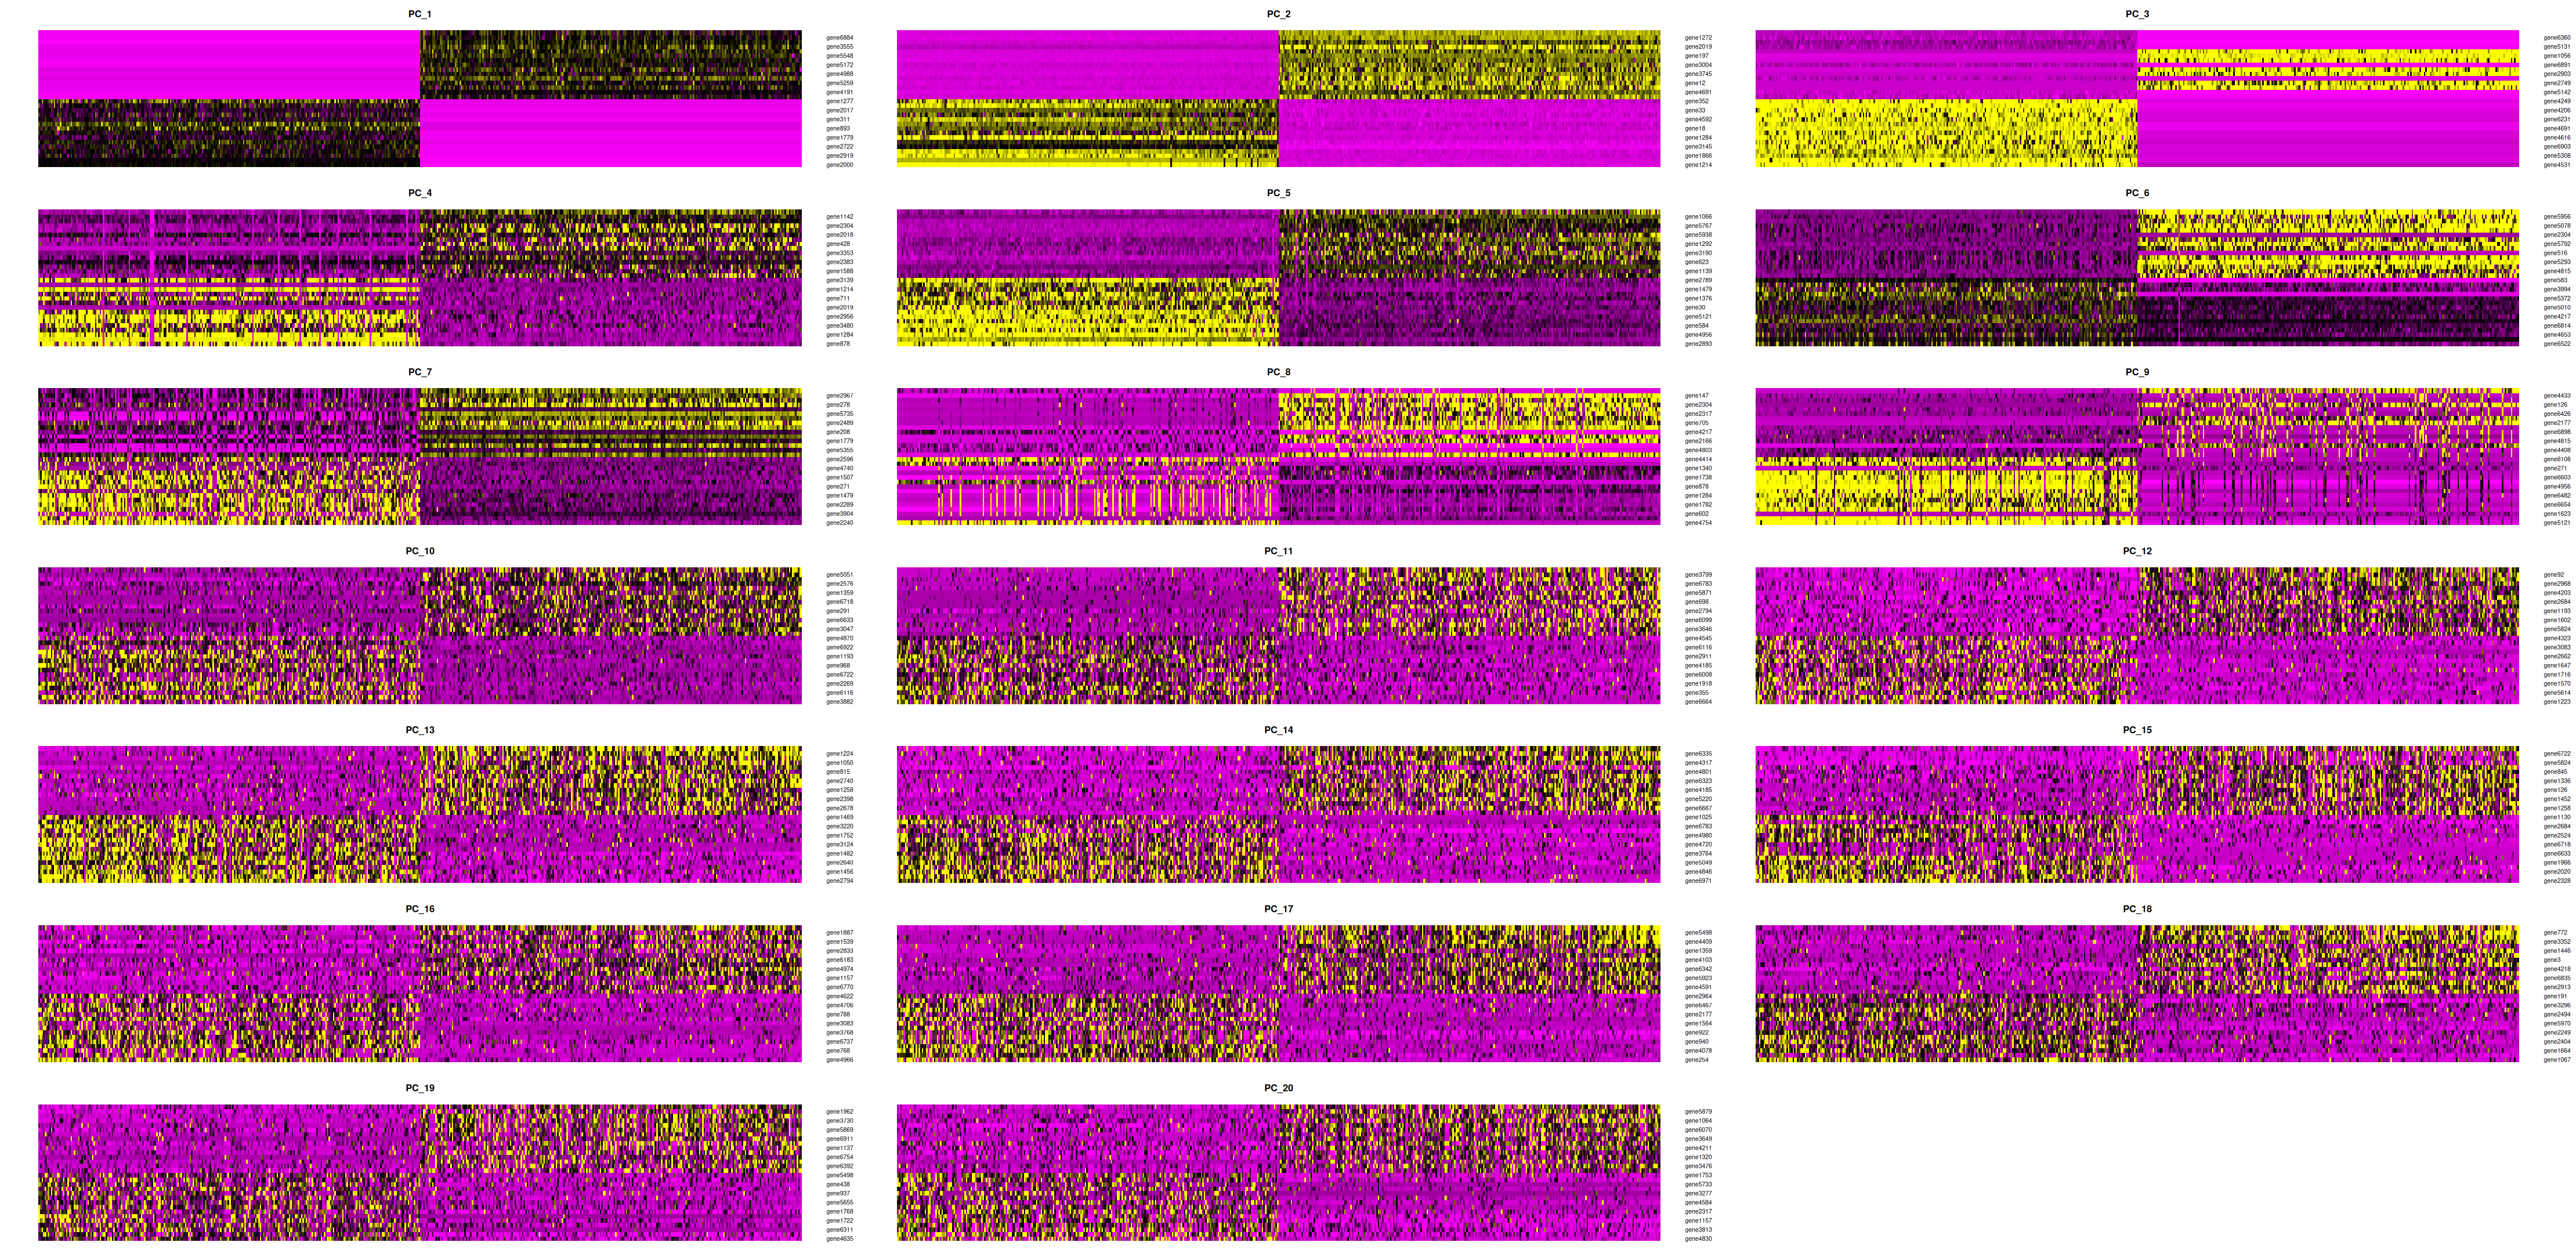

In [24]:
options(repr.plot.width =37, repr.plot.height=18)


DimHeatmap(seurat_obj, dims = 1:20, cells = 500, balanced = TRUE)


##### 15 pc

In [26]:
seurat_sim <- RunPCA(seurat_obj, npcs = 30, verbose = FALSE)
seurat_sim <- FindNeighbors(seurat_obj,dims = 1:30,reduction = 'pca') %>%

FindClusters(resolution = 0.5) %>%

RunUMAP( dims = 1:30) %>% RunTSNE()

Warning message:
“Number of dimensions changing from 50 to 30”
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 24000
Number of edges: 881724

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9418
Number of communities: 17
Elapsed time: 1 seconds


14:30:15 UMAP embedding parameters a = 0.9922 b = 1.112

14:30:15 Read 24000 rows and found 30 numeric columns

14:30:15 Using Annoy for neighbor search, n_neighbors = 30

14:30:15 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

14:30:16 Writing NN index file to temp file /tmp/Rtmp7puYsZ/file39751657746708

14:30:16 Searching Annoy index using 1 thread, search_k = 3000

14:30:22 Annoy recall = 100%

14:30:22 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

14:30:24 Found 3 connected components, 
falling back to 'spca' initialization with init_sdev = 1

14:30:24 Using 'irlba' for PCA

14:30:24 PCA: 2 components explained 71.21% variance

14:30:24 Scaling init to sdev = 1

14:30:24 Commencing optimization for 200 epochs, with 10172

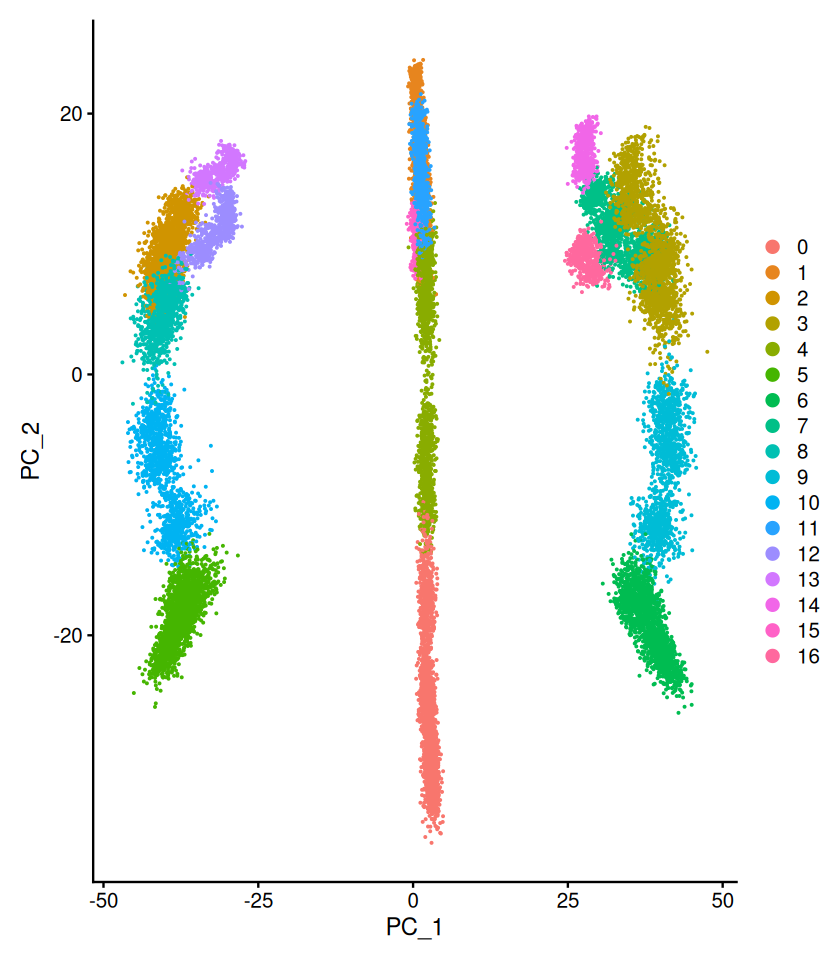

In [27]:
options(repr.plot.width =7, repr.plot.height=8)

# DimPlot(combined_seurat_filtered, group.by = c("seurat_clusters", "batch","Cell_Type" ), reduction = 'umap',label = FALSE)  # group
DimPlot(seurat_sim, reduction = 'pca', label = FALSE)  # batch
#  DimPlot(sesplater_sim,group.by = "Cell_Type", label = FALSE)                      # cluster

### DivideBatches

In [80]:
?DivideBatches( )

In [88]:
ls()

[1] "count_mat"        "count1"           "count2"           "count3"          
 [5] "match_params"     "pca_df"           "pca_res"          "seurat_obj"      
 [9] "seurat_sim"       "true_counts_res"  "tsne_df"          "tsne_out"        
[13] "tsne_true_counts"

In [89]:
class(true_counts_res[["cell_meta"]])

[1] "data.frame"

In [95]:
head(meta_cell)

,as.factor(colnames(count1))
,<fct>
1,cell1
2,cell2
3,cell3
4,cell4
5,cell5
6,cell6


In [28]:
my_batch <- function(observed_counts, nbatch, batch_effect_size,seed){
    meta_cell <- as.data.frame(as.factor(colnames(observed_counts)))
    ncells <- dim(observed_counts)[2]
    ngenes <- dim(observed_counts)[1]

set.seed(seed)
# nbatch <- 4 
batchIDs <- sample(1:nbatch, ncells, replace = TRUE)

meta_cell2 <- data.frame(batch = batchIDs, stringsAsFactors = F)
meta_cell <- cbind(meta_cell, meta_cell2)
colnames(meta_cell) <- c('cellID','batch')

    mean_matrix <- matrix(0, ngenes, nbatch)
    gene_mean <- rnorm(ngenes, 0, 1)


batch_effect_size <-batch_effect_size
temp <- lapply(1:ngenes, function(igene) {
        return(runif(nbatch, min = gene_mean[igene] - batch_effect_size, 
            max = gene_mean[igene] + batch_effect_size))
    })

 mean_matrix <- do.call(rbind, temp)

batch_factor <- matrix(0, ngenes, ncells)
    for (igene in 1:ngenes) {
        for (icell in 1:ncells) {
            batch_factor[igene, icell] <- rnorm(n = 1, mean = mean_matrix[igene, 
                batchIDs[icell]], sd = 0.01)
        }
    }

count1_b <- round(2^(log2(observed_counts) + batch_factor))

    obj <- list(count1_b,meta_cell)
    
    names(obj) <- c('count','batch_label')

    return(obj)
    
}

In [30]:
test <- my_batch(observed_counts = count1,nbatch = 5,batch_effect_size = 0.5,seed = 123)

In [31]:
class(test)


head(test$batch_label)

[1] "list"

,cellID,batch
,<fct>,<int>
1,cell1,3
2,cell2,3
3,cell3,2
4,cell4,2
5,cell5,3
6,cell6,5


In [32]:
test2 <- my_batch(observed_counts = count2,nbatch = 4,batch_effect_size = 0.5,seed = 123)

In [33]:
test3 <- my_batch(observed_counts = count3,nbatch = 4,batch_effect_size = 0.5,seed = 123)

In [34]:
count_mat_b <- cbind(cbind(test$count,test2$count ),test3$count)

In [35]:
count_mat_b[1:10,1:5]

test$batch_label %>% head()

,cell1,cell2,cell3,cell4,cell5
gene1,9,1,5,9,4
gene2,1123,1252,1136,1639,666
gene3,2,35,4,6,2
gene4,88,144,63,116,31
gene5,36,15,53,21,49
gene6,0,0,0,0,0
gene7,86,77,79,68,54
gene8,12,1,20,7,2
gene9,142,127,95,86,136
gene10,4,79,12,95,70


,cellID,batch
,<fct>,<int>
1,cell1,3
2,cell2,3
3,cell3,2
4,cell4,2
5,cell5,3
6,cell6,5


In [36]:
meta_data1 <- test$batch_label

meta_data1$batch <- paste0('1_',meta_data1$batch)

meta_data2 <- test2$batch_label

meta_data2$batch <- paste0('2_',meta_data2$batch)

meta_data3 <- test3$batch_label

meta_data3$batch <- paste0('3_',meta_data3$batch)


In [37]:
metalabel <-rbind( rbind(meta_data1,meta_data2),meta_data3)

rownames(metalabel) <- metalabel$cellID
tail(metalabel)

,cellID,batch
,<fct>,<chr>
tcell7995,tcell7995,3_2
tcell7996,tcell7996,3_2
tcell7997,tcell7997,3_1
tcell7998,tcell7998,3_1
tcell7999,tcell7999,3_2
tcell8000,tcell8000,3_1


In [38]:
seurat_obj <- CreateSeuratObject(counts = count_mat_b,meta.data = metalabel)


seurat_obj <- NormalizeData(seurat_obj) %>%

    FindVariableFeatures( selection.method = "vst", nfeatures = 3000)%>%

    ScaleData()

seurat_obj <- RunPCA(seurat_obj, npcs = 50, verbose = FALSE)

Centering and scaling data matrix



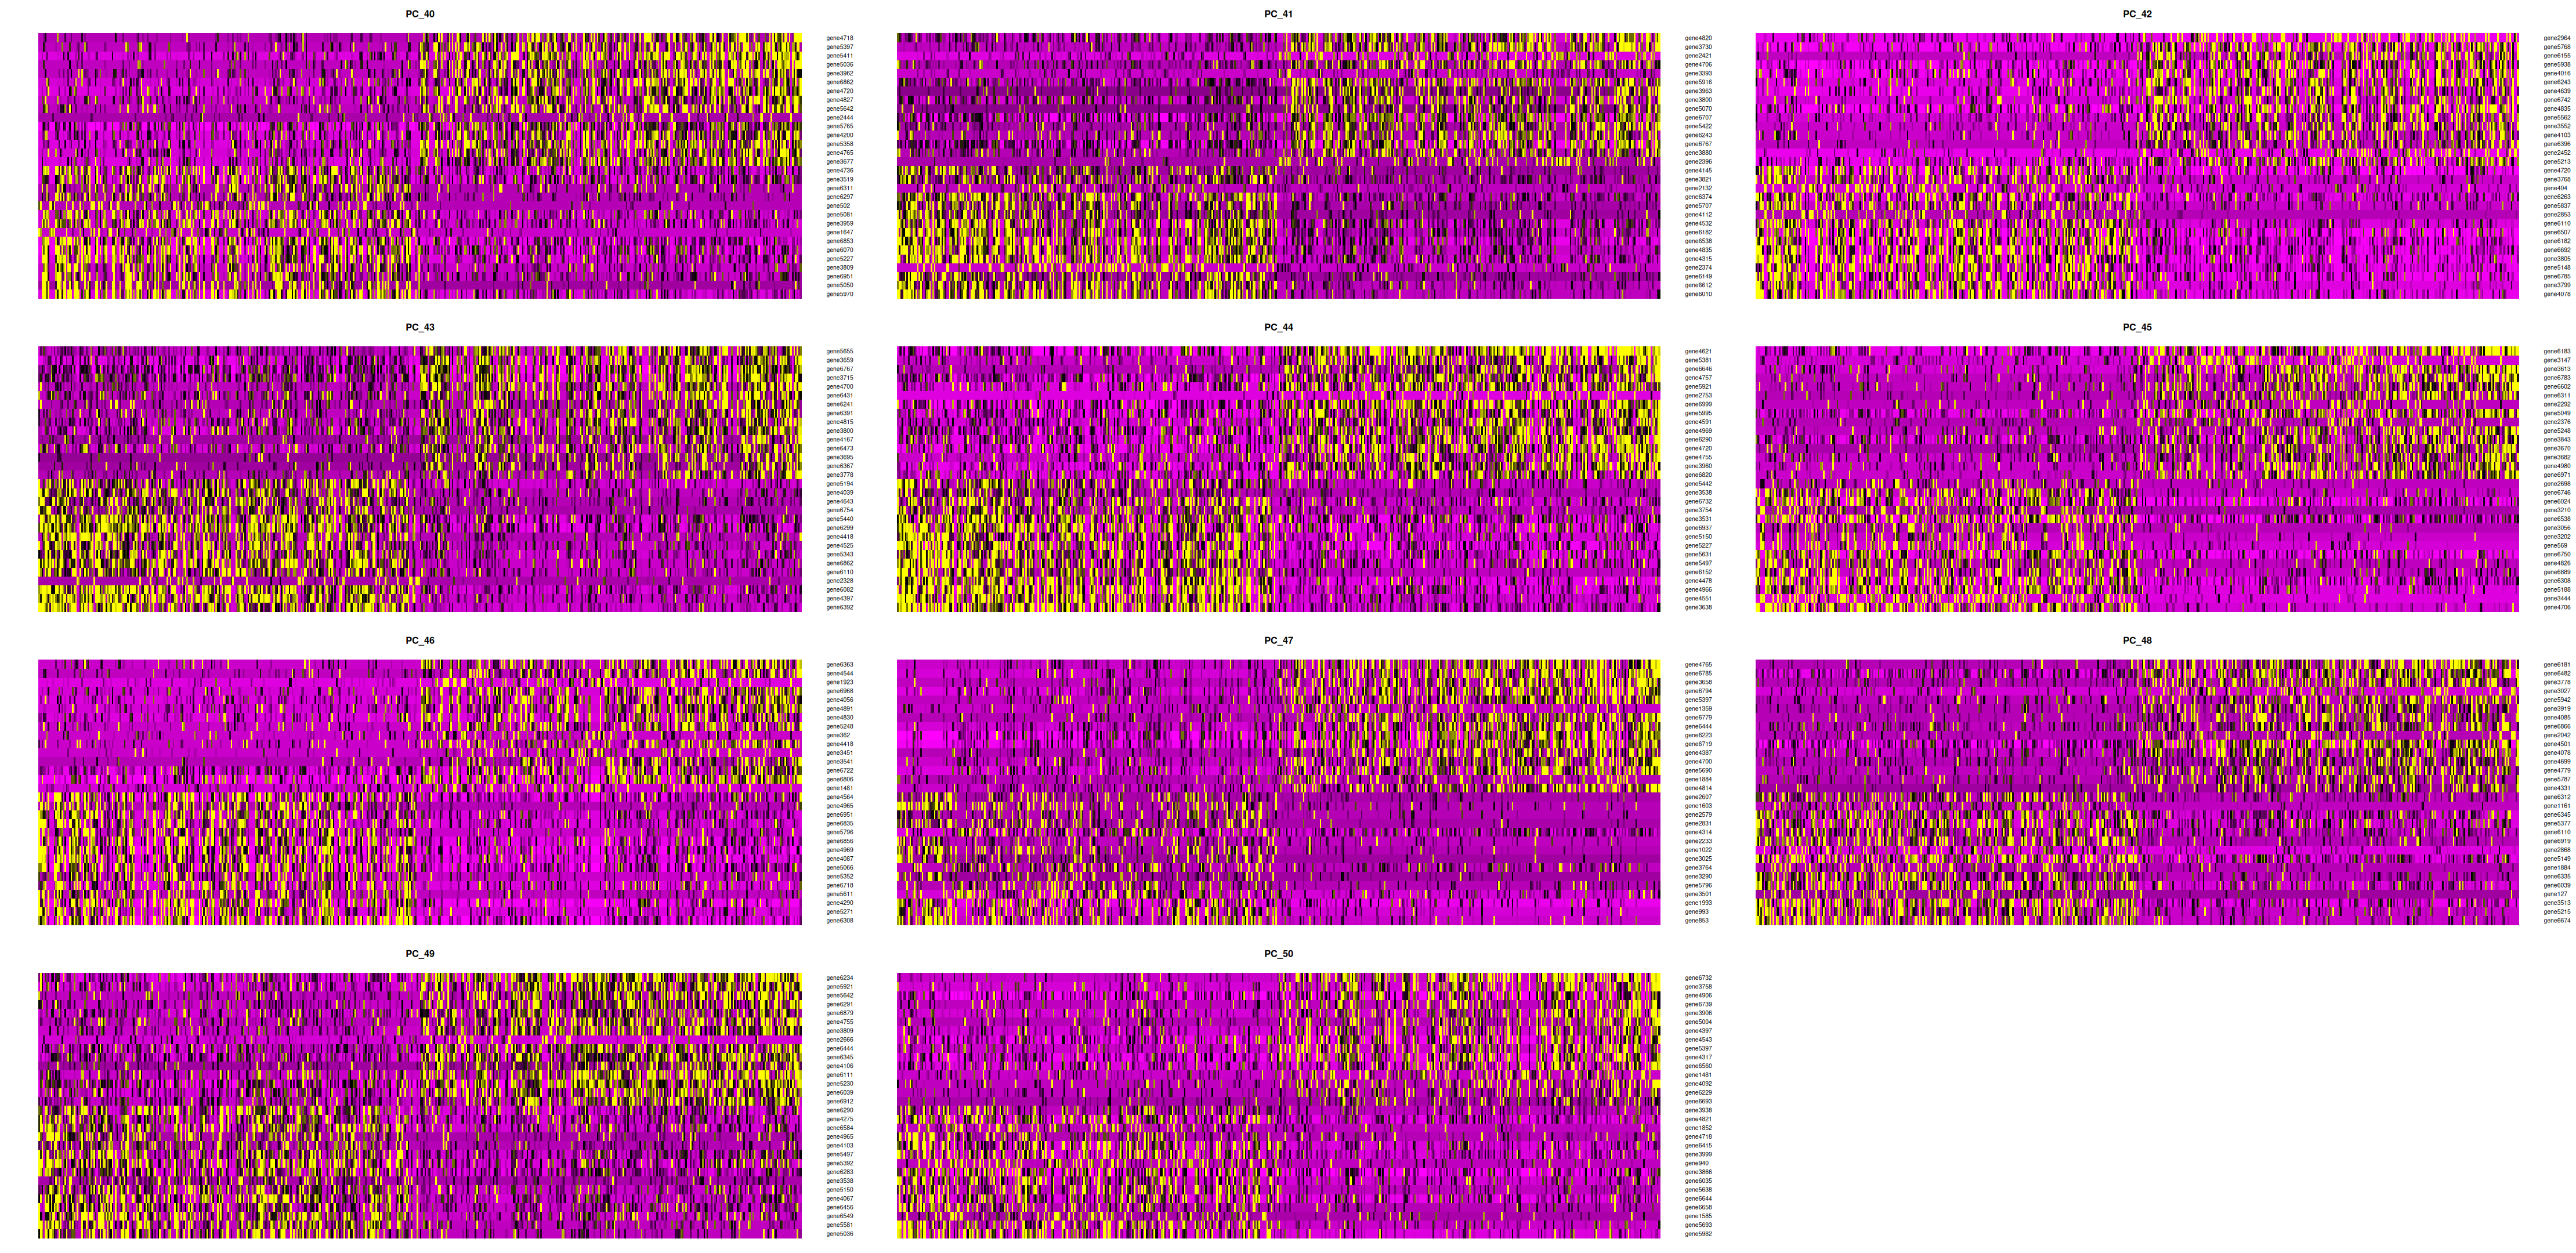

In [40]:
options(repr.plot.width =37, repr.plot.height=18)


DimHeatmap(seurat_obj, dims = 40:50, cells = 500, balanced = TRUE)

In [ ]:
seurat_sim <- RunPCA(seurat_obj, npcs = 50, verbose = FALSE)

seurat_sim <- FindNeighbors(seurat_obj,dims = 1:50,reduction = 'pca') %>%

FindClusters(resolution = 0.5) %>%

RunUMAP( dims = 1:50) %>% RunTSNE()

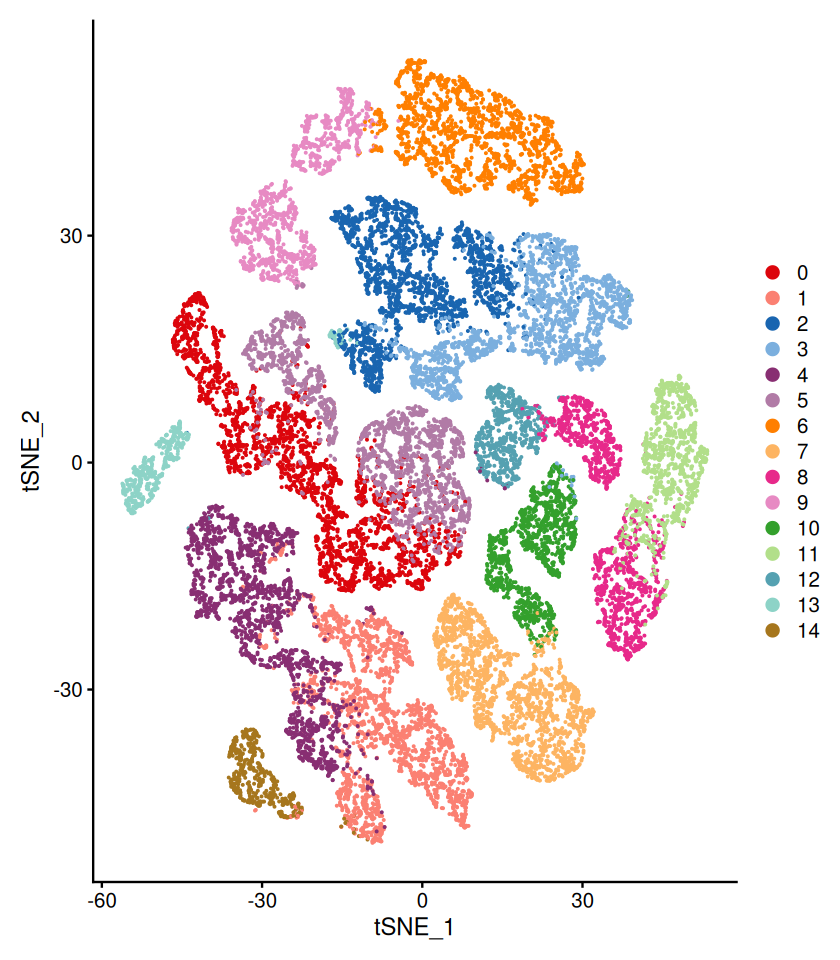

In [42]:
options(repr.plot.width =7, repr.plot.height=8)

# DimPlot(combined_seurat_filtered, group.by = c("seurat_clusters", "batch","Cell_Type" ), reduction = 'umap',label = FALSE)  # group
DimPlot(seurat_sim, reduction = 'tsne', label = FALSE,cols = cluster_cols)  # batch
#  DimPlot(sesplater_sim,group.by = "Cell_Type", label = FALSE)                      # cluster

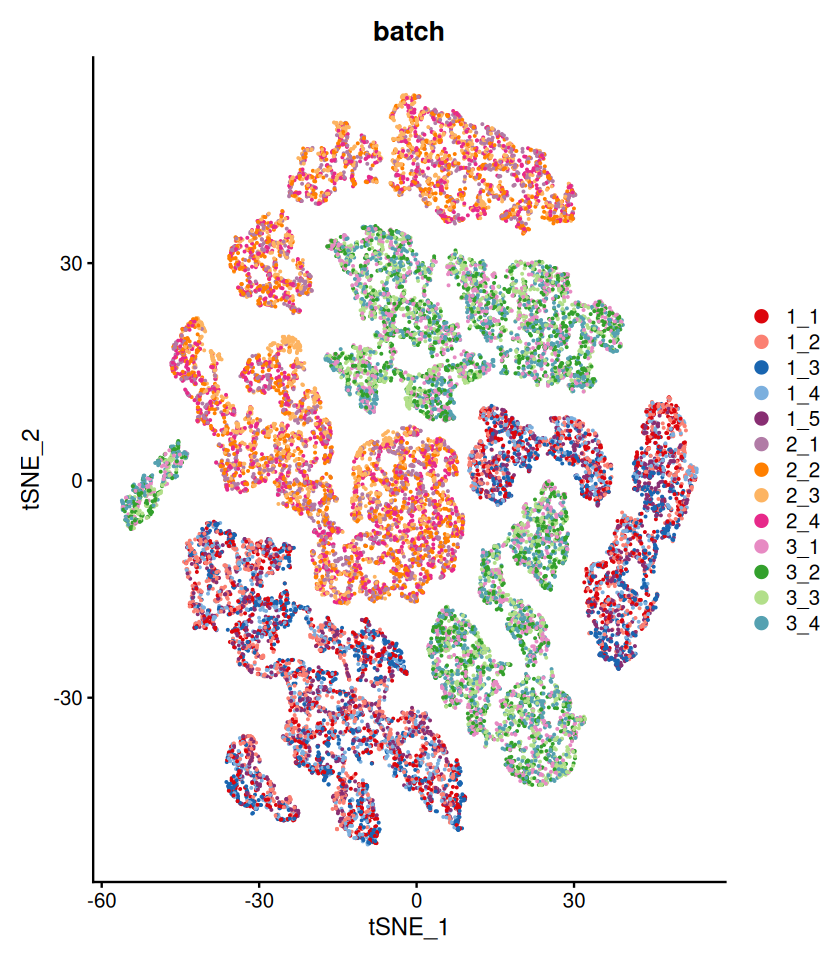

In [43]:
options(repr.plot.width =7, repr.plot.height=8)

# DimPlot(combined_seurat_filtered, group.by = c("seurat_clusters", "batch","Cell_Type" ), reduction = 'umap',label = FALSE)  # group
DimPlot(seurat_sim, reduction = 'tsne', group.by ='batch',
        label = FALSE,cols = cluster_cols)  # batch
#  DimPlot(sesplater_sim,group.by = "Cell_Type", label = FALSE)                      # cluster

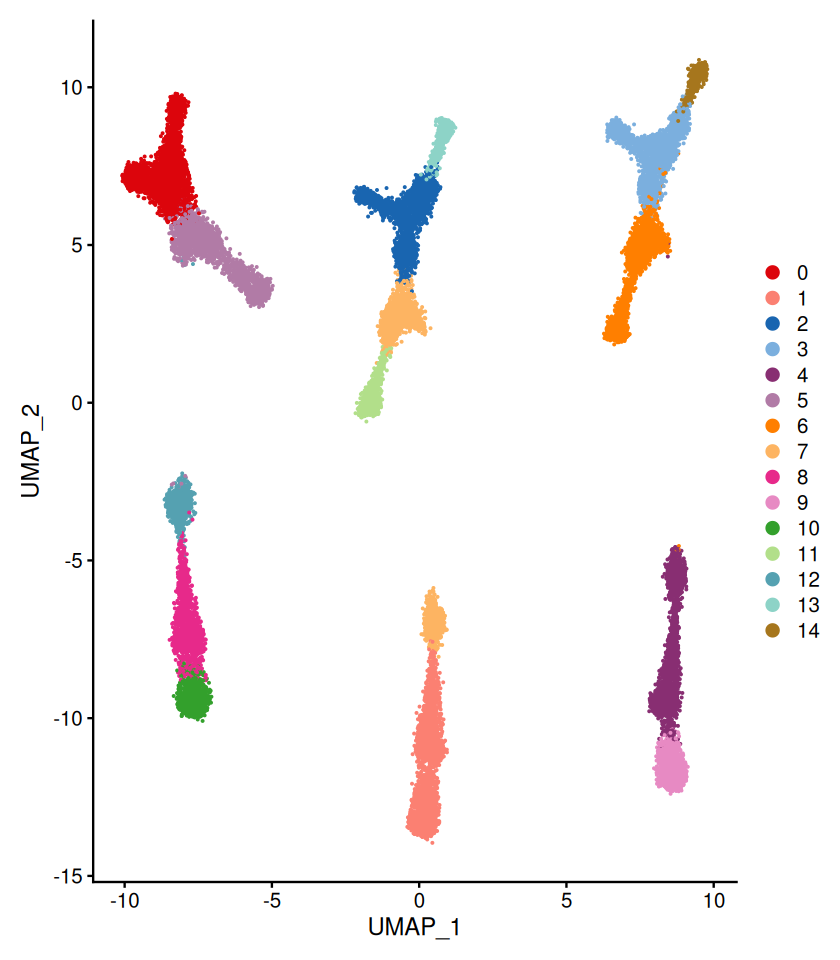

In [49]:
options(repr.plot.width =7, repr.plot.height=8)

# DimPlot(combined_seurat_filtered, group.by = c("seurat_clusters", "batch","Cell_Type" ), reduction = 'umap',label = FALSE)  # group
DimPlot(seurat_sim, reduction = 'umap', 
        label = FALSE,cols = cluster_cols)  # batch
#  DimPlot(sesplater_sim,group.by = "Cell_Type", label = FALSE)                      # cluster

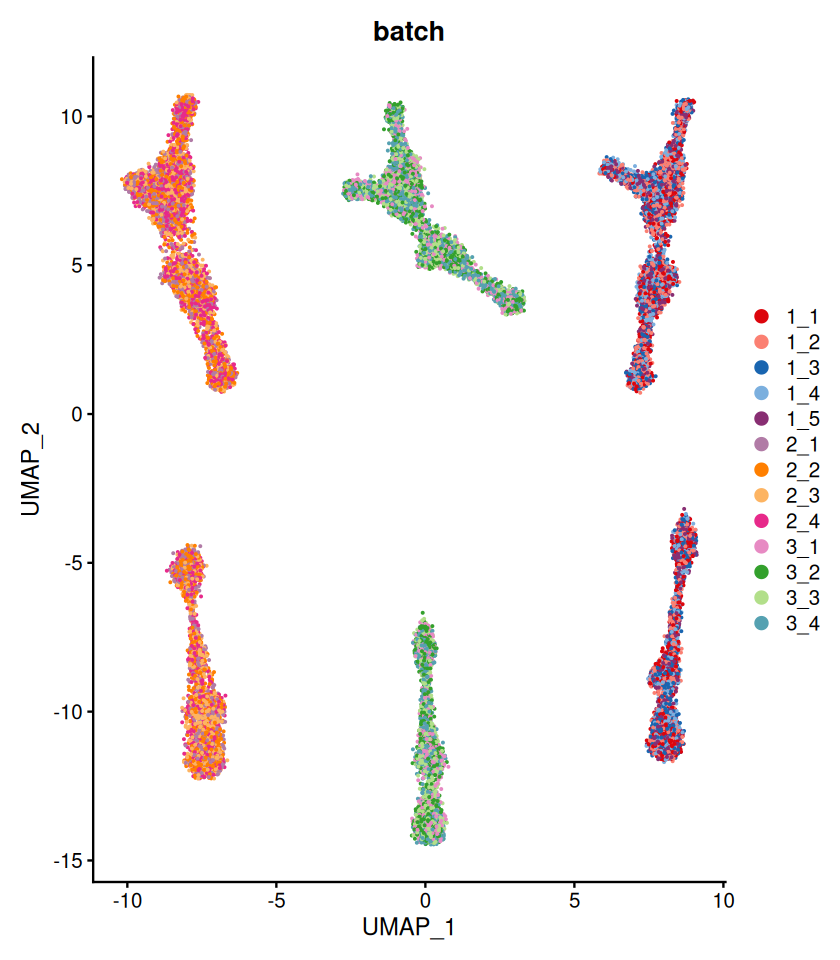

In [44]:
options(repr.plot.width =7, repr.plot.height=8)

# DimPlot(combined_seurat_filtered, group.by = c("seurat_clusters", "batch","Cell_Type" ), reduction = 'umap',label = FALSE)  # group
DimPlot(seurat_sim, reduction = 'umap', group.by ='batch',
        label = FALSE,cols = cluster_cols)  # batch
#  DimPlot(sesplater_sim,group.by = "Cell_Type", label = FALSE)                      # cluster

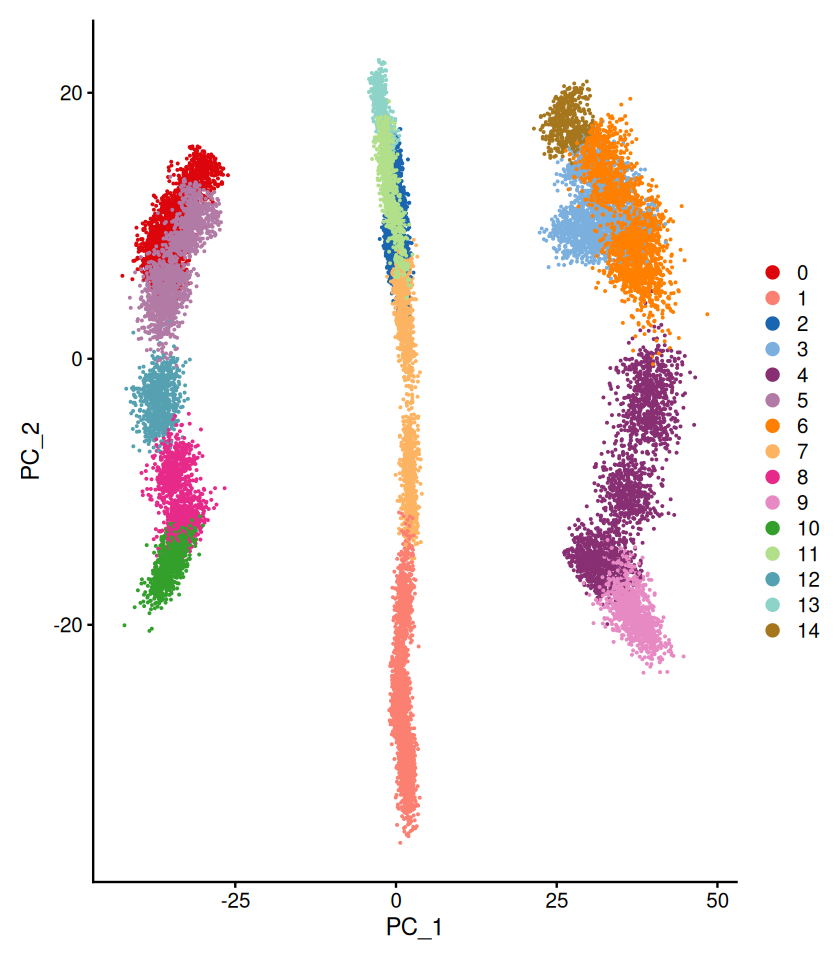

In [47]:
options(repr.plot.width =7, repr.plot.height=8)

# DimPlot(combined_seurat_filtered, group.by = c("seurat_clusters", "batch","Cell_Type" ), reduction = 'umap',label = FALSE)  # group
DimPlot(seurat_sim, reduction = 'pca', label = FALSE,cols = cluster_cols)  # batch
#  DimPlot(sesplater_sim,group.by = "Cell_Type", label = FALSE)                      # cluster

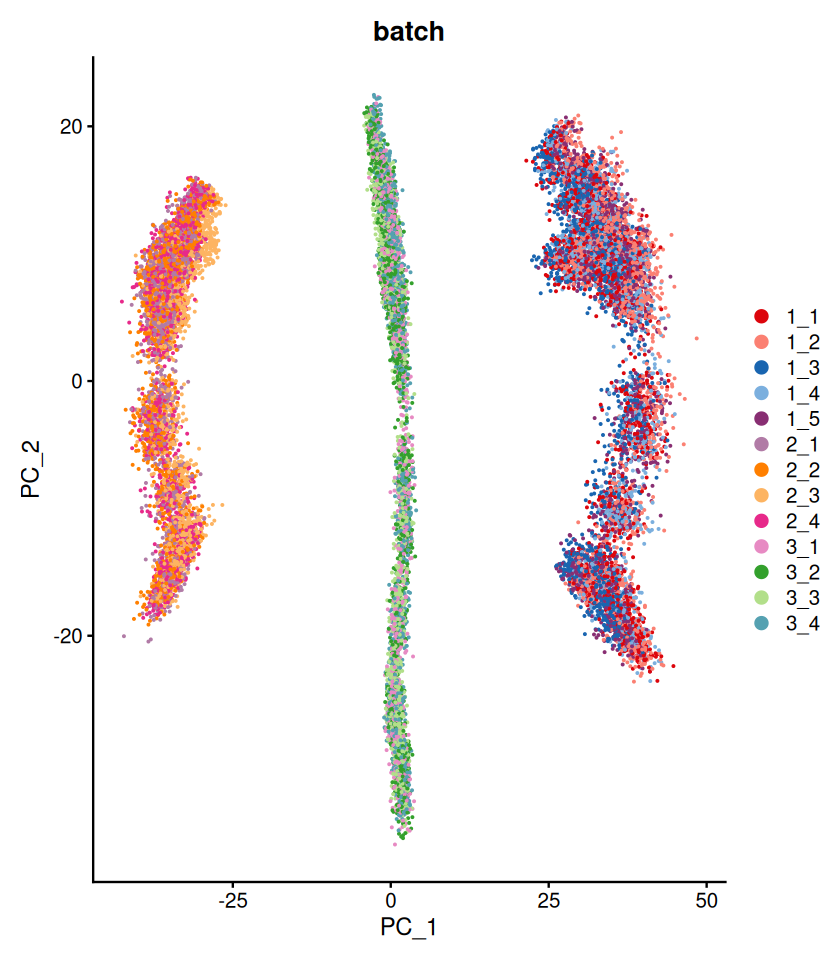

In [48]:
options(repr.plot.width =7, repr.plot.height=8)

# DimPlot(combined_seurat_filtered, group.by = c("seurat_clusters", "batch","Cell_Type" ), reduction = 'umap',label = FALSE)  # group
DimPlot(seurat_sim, reduction = 'pca',group.by = 'batch' ,label = FALSE,cols = cluster_cols)  # batch
#  DimPlot(sesplater_sim,group.by = "Cell_Type", label = FALSE)                      # cluster

In [50]:
saveRDS(seurat_sim, './03_seurat_sim.rds')

# nmf

In [51]:
head(seurat_sim@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,cellID,batch,RNA_snn_res.0.5,seurat_clusters
,<fct>,<dbl>,<int>,<fct>,<chr>,<fct>,<fct>
cell1,SeuratProject,456117,3049,cell1,1_3,4,4
cell2,SeuratProject,414289,2995,cell2,1_3,4,4
cell3,SeuratProject,381112,3061,cell3,1_2,4,4
cell4,SeuratProject,393819,3160,cell4,1_2,4,4
cell5,SeuratProject,428976,3043,cell5,1_3,4,4
cell6,SeuratProject,397950,3075,cell6,1_5,4,4


In [53]:

Idents(seurat_sim) <- 'batch'

split_list <- SplitObject(seurat_sim,split.by = 'batch' )

split_list

$`1_3`
An object of class Seurat 
7000 features across 1604 samples within 1 assay 
Active assay: RNA (7000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

$`1_2`
An object of class Seurat 
7000 features across 1643 samples within 1 assay 
Active assay: RNA (7000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

$`1_5`
An object of class Seurat 
7000 features across 1586 samples within 1 assay 
Active assay: RNA (7000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

$`1_4`
An object of class Seurat 
7000 features across 1524 samples within 1 assay 
Active assay: RNA (7000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

$`1_1`
An object of class Seurat 
70

In [54]:
#Select HVGs form every sample separatly
hvgs_list <- lapply(split_list, function(seurat_obj) {


    seurat_obj <- FindVariableFeatures(seurat_obj, selection.method = "vst", nfeatures = 3000)
  
    
  VariableFeatures(seurat_obj)
})


names(hvgs_list) <- names(split_list)


In [55]:
all_hvgs <- unlist(hvgs_list)

hvg_counts <- table(all_hvgs)

head(hvg_counts)

hvg_freq_df <- data.frame(
  gene = names(hvg_counts),
  frequency = as.integer(hvg_counts)
)

hvg_freq_df <- hvg_freq_df[order(-hvg_freq_df$frequency), ]

all_hvgs
   gene1   gene10  gene100 gene1000 gene1001 gene1002 
       5        5        5        7        9        9 

In [56]:
hvg_freq_df[3000,]

,gene,frequency
,<chr>,<int>
5869,gene6985,7


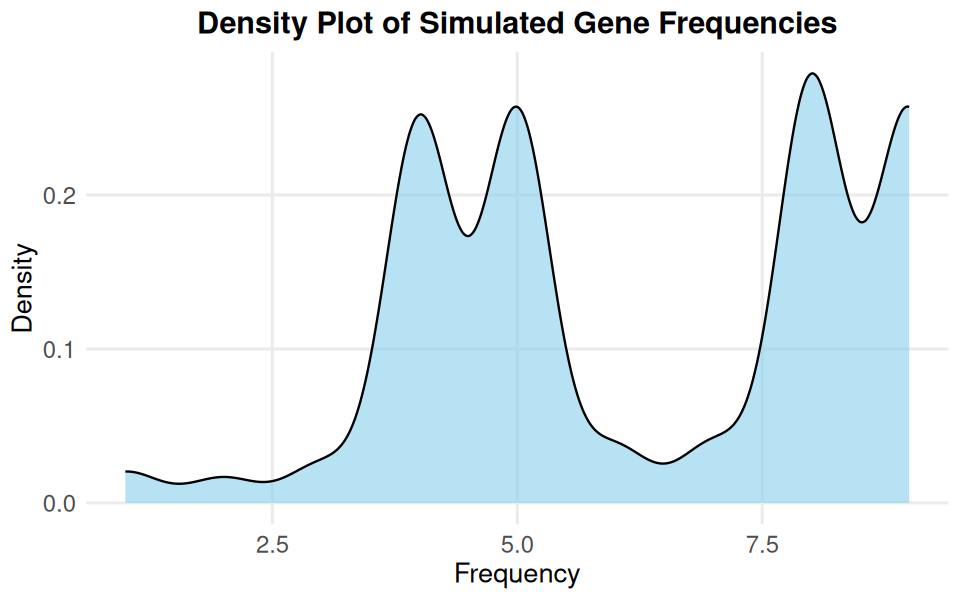

In [57]:
options(repr.plot.width =8, repr.plot.height=5)

ggplot(hvg_freq_df, aes(x = frequency)) +
  geom_density(fill = "skyblue", alpha = 0.6) +
  theme_minimal(base_size = 14) +  
  labs(
    title = "Density Plot of Simulated Gene Frequencies",
    x = "Frequency",
    y = "Density"
  ) +
  theme(
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),  
    axis.title = element_text(size = 16),
    axis.text = element_text(size = 14),
    panel.grid.minor = element_blank() 
  )


In [58]:
HVGs <- head(hvg_freq_df$gene,3000)

dir <- "/mnt/fast00/Minghui/Simulate_data/"

for (i in names(split_list)) {

     sample_dir <- file.path(dir, i)
  if (!dir.exists(sample_dir)) dir.create(sample_dir, recursive = TRUE)

  # 提取并归一化
  obj <- ScaleData(split_list[[i]], features = HVGs, do.center = FALSE, verbose = FALSE)
  data <- GetAssayData(obj, slot = "scale.data") %>% as.matrix()
  
  # 负数归零
  data[data < 0] <- 0
  
  # 修复方差为 0 的行
  zero_var_rows <- which(apply(data, 1, var) == 0)
  for (j in zero_var_rows) {
    col_index <- sample(ncol(data), 1)
    data[j, col_index] <- 1e-10
  }

  # 保存为 txt 文件到对应子目录
  out_file <- file.path(sample_dir, "scaled_matrix.txt")
  write.table(data, file = out_file, sep = "\t", quote = FALSE, row.names = FALSE,col.names = FALSE)

  message("Scaled matrix saved: ", out_file)
}


Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//1_3/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//1_2/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//1_5/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//1_4/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//1_1/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//2_3/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//2_2/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//2_1/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//2_4/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//3_3/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//3_2/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//3_1/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_da

In [59]:
w_dir <- "/mnt/fast00/Minghui/Simulate_data/output_csv"


target_files <- sapply(names(split_list), function(sample_name) {
#   k_value <- sample_k_list[[sample_name]]
  file.path(w_dir, paste0(sample_name, "_k", 10, "_theta03_W.csv"))
}, USE.NAMES = TRUE)

print(target_files)


                                                                 1_3 
"/mnt/fast00/Minghui/Simulate_data/output_csv/1_3_k10_theta03_W.csv" 
                                                                 1_2 
"/mnt/fast00/Minghui/Simulate_data/output_csv/1_2_k10_theta03_W.csv" 
                                                                 1_5 
"/mnt/fast00/Minghui/Simulate_data/output_csv/1_5_k10_theta03_W.csv" 
                                                                 1_4 
"/mnt/fast00/Minghui/Simulate_data/output_csv/1_4_k10_theta03_W.csv" 
                                                                 1_1 
"/mnt/fast00/Minghui/Simulate_data/output_csv/1_1_k10_theta03_W.csv" 
                                                                 2_3 
"/mnt/fast00/Minghui/Simulate_data/output_csv/2_3_k10_theta03_W.csv" 
                                                                 2_2 
"/mnt/fast00/Minghui/Simulate_data/output_csv/2_2_k10_theta03_W.csv" 
                    

In [60]:
w_dir <- "/mnt/fast00/Minghui/Simulate_data/output_csv"


target_files <- sapply(names(split_list), function(sample_name) {
#   k_value <- sample_k_list[[sample_name]]
  file.path(w_dir, paste0(sample_name, "_k", 8, "_theta03_W.csv"))
}, USE.NAMES = TRUE)

print(target_files)


                                                                1_3 
"/mnt/fast00/Minghui/Simulate_data/output_csv/1_3_k8_theta03_W.csv" 
                                                                1_2 
"/mnt/fast00/Minghui/Simulate_data/output_csv/1_2_k8_theta03_W.csv" 
                                                                1_5 
"/mnt/fast00/Minghui/Simulate_data/output_csv/1_5_k8_theta03_W.csv" 
                                                                1_4 
"/mnt/fast00/Minghui/Simulate_data/output_csv/1_4_k8_theta03_W.csv" 
                                                                1_1 
"/mnt/fast00/Minghui/Simulate_data/output_csv/1_1_k8_theta03_W.csv" 
                                                                2_3 
"/mnt/fast00/Minghui/Simulate_data/output_csv/2_3_k8_theta03_W.csv" 
                                                                2_2 
"/mnt/fast00/Minghui/Simulate_data/output_csv/2_2_k8_theta03_W.csv" 
                                  

In [61]:
names(target_files)

[1] "1_3" "1_2" "1_5" "1_4" "1_1" "2_3" "2_2" "2_1" "2_4" "3_3" "3_2" "3_1"
[13] "3_4"

In [62]:
w_list <- lapply(target_files, function(f) {
  as.matrix(read.csv(f, header = FALSE))
})


names(w_list) <- names(target_files)


print(names(w_list))


 [1] "1_3" "1_2" "1_5" "1_4" "1_1" "2_3" "2_2" "2_1" "2_4" "3_3" "3_2" "3_1"
[13] "3_4"


In [63]:
gene_names <- HVGs

w_list <- lapply(names(w_list), function(sample_name) {
  mat <- w_list[[sample_name]]
  
  rownames(mat) <- gene_names
  colnames(mat) <- paste0(sample_name, "_Program_", seq_len(ncol(mat)))
  
  return(mat)
})

names(w_list) <- names(w_list)

In [64]:
merge_matrix <- do.call(cbind ,w_list)
mat_unit <- apply(merge_matrix, 2, function(x) x / sqrt(sum(x^2))) #L2 normalize the columns
                

,1_3_Program_1,1_3_Program_2,1_3_Program_3,1_3_Program_4,1_3_Program_5,1_3_Program_6,1_3_Program_7,1_3_Program_8,1_2_Program_1,1_2_Program_2,⋯,3_1_Program_7,3_1_Program_8,3_4_Program_1,3_4_Program_2,3_4_Program_3,3_4_Program_4,3_4_Program_5,3_4_Program_6,3_4_Program_7,3_4_Program_8
gene1001,8.037752e-10,0.05769999,1.249326e-09,3.235913e-02,3.583017e-02,1.008830e-09,1.339536e-09,1.306269e-09,3.865550e-02,9.452781e-10,⋯,1.698504e-05,2.235141e-02,2.559330e-02,1.965735e-02,0.030377934,6.613335e-10,8.708099e-10,7.238536e-04,9.226546e-10,6.794000e-10
gene1002,2.916083e-03,0.05297938,2.786433e-02,3.196980e-02,2.215547e-02,1.649082e-02,1.339536e-09,3.495352e-02,4.210278e-02,1.193085e-02,⋯,8.801657e-10,1.707060e-02,2.617378e-02,1.669107e-02,0.035598096,6.613335e-10,6.555909e-03,3.914050e-03,1.978582e-02,6.675078e-03
gene1005,8.037752e-10,0.01076881,6.161201e-03,1.685216e-02,9.353752e-03,1.008830e-09,1.339536e-09,1.306269e-09,1.416717e-02,9.452781e-10,⋯,8.170765e-03,1.167427e-02,1.052364e-02,6.122574e-03,0.008049283,6.613335e-10,6.945376e-03,9.911584e-10,9.226546e-10,6.794000e-10
gene1007,8.405337e-03,0.03736231,3.108354e-02,1.421927e-02,2.831473e-02,6.546961e-03,4.867064e-02,2.052620e-02,1.229838e-02,8.481856e-03,⋯,1.677348e-02,1.860008e-02,5.218544e-03,1.895780e-02,0.027315078,7.860395e-03,2.233932e-02,1.462115e-02,4.339137e-02,5.945646e-03
gene1008,2.546341e-02,0.02454717,4.173444e-02,1.377995e-02,1.028256e-09,4.718171e-02,1.339536e-09,1.269307e-02,8.077834e-03,4.048024e-02,⋯,2.238671e-02,7.574076e-10,6.345328e-03,7.497331e-10,0.023544040,1.592244e-02,1.689756e-02,9.911584e-10,3.175549e-02,3.133740e-02
gene101,4.079987e-02,0.01977284,1.794509e-02,8.924234e-10,1.028256e-09,2.994086e-02,6.581122e-02,1.516460e-02,8.858936e-10,3.567051e-02,⋯,1.209352e-02,7.574076e-10,6.202400e-10,7.497331e-10,0.006419157,3.323536e-02,4.330014e-03,5.453795e-02,1.489814e-02,2.429879e-02


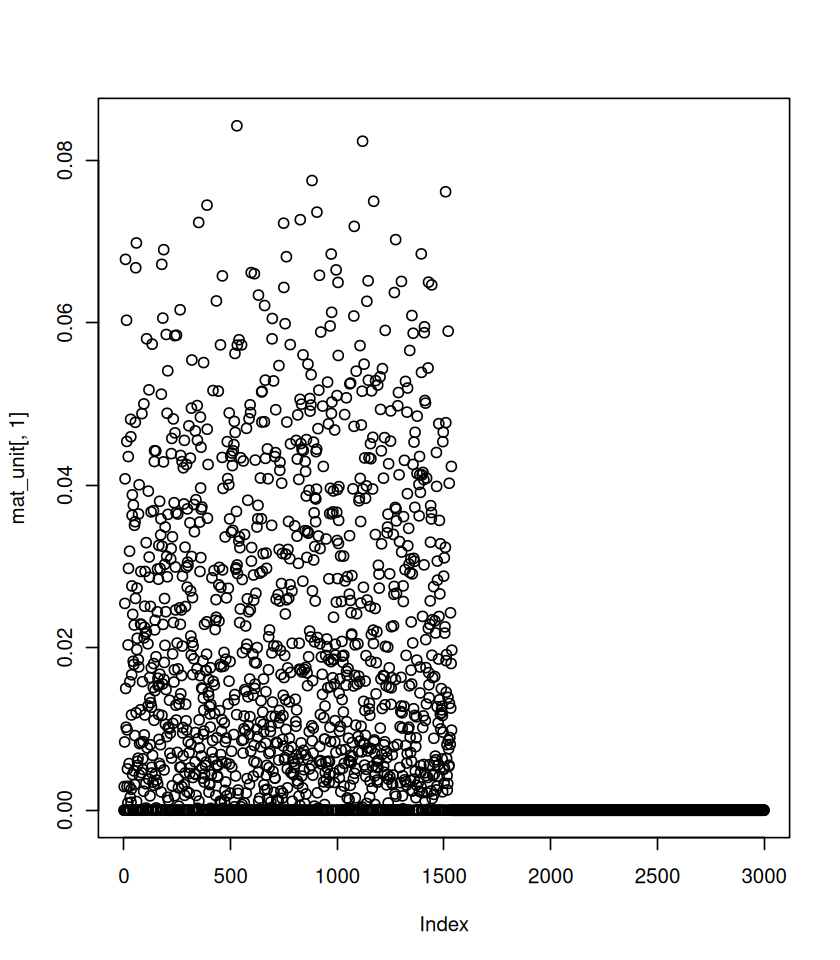

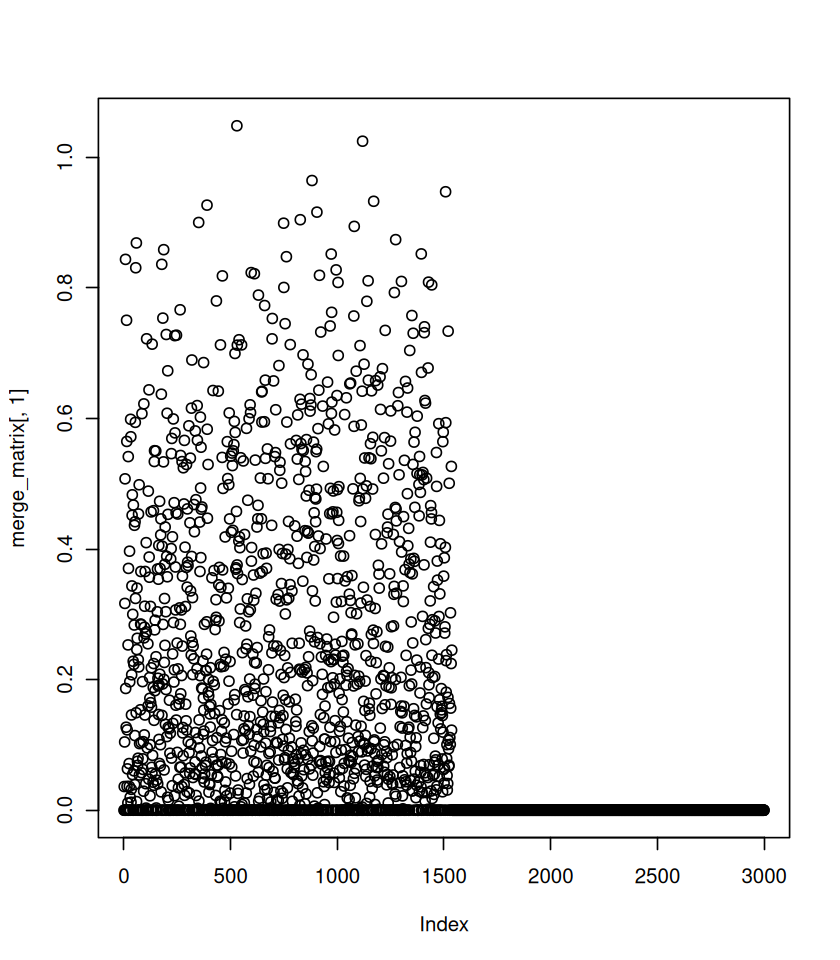

In [65]:
options(repr.plot.width =7, repr.plot.height=8)

head(mat_unit)

plot(mat_unit[,1])

plot(merge_matrix[,1])


In [67]:
library(cluster)



Attaching package: ‘cluster’


The following object is masked from ‘package:maps’:

    votes.repub




In [68]:
pam_data <- pam(t(mat_unit),20 )

names(pam_data)

[1] "medoids"    "id.med"     "clustering" "objective"  "isolation" 
 [6] "clusinfo"   "silinfo"    "diss"       "call"       "data"

Loading required package: permute


Attaching package: ‘vegan’


The following object is masked from ‘package:phytools’:

    scores


Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’



[1] 0.6227710 0.6328668 0.7340652 0.6938050 0.3935217 0.4630901

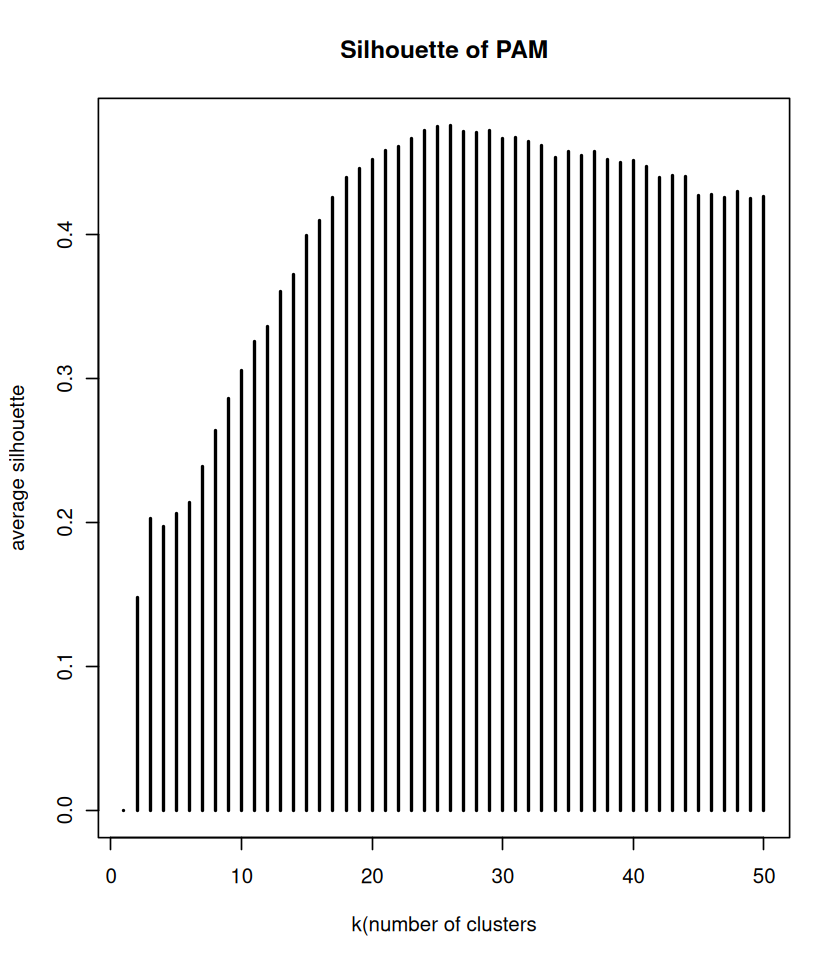

In [69]:
library(vegan)

otu_dist=vegdist(t(mat_unit), method="bray", diag=TRUE, upper=TRUE, p=2)

head(otu_dist)

library(fpc)
library(cluster)
pambest=pamk(otu_dist)
k=pambest$nc

asw <- numeric(50)
for (i in 2:50) {
  asw[i]=pam(otu_dist, i)$silinfo$avg.width
}
k.best=which.max(asw)
plot(1:length(asw), asw, type="h", main="Silhouette of PAM", lwd=2,
     xlab="k(number of clusters", ylab="average silhouette")

In [70]:
k.best

[1] 26

In [71]:
k = k.best

pam_data <- pam(t(mat_unit),k )
medoid_names <- pam_data$medoids

medoid_vectors <- mat_unit[, rownames( pam_data$medoids)]

w_list <- lapply(target_files, function(f) {
  as.matrix(read.csv(f, header = FALSE))
})

names(w_list) <- names(target_files)

print(names(w_list))


 [1] "1_3" "1_2" "1_5" "1_4" "1_1" "2_3" "2_2" "2_1" "2_4" "3_3" "3_2" "3_1"
[13] "3_4"


In [72]:
head(medoid_vectors)

dim(medoid_vectors)

,1_5_Program_2,1_4_Program_6,1_5_Program_6,1_1_Program_2,1_4_Program_5,1_1_Program_3,1_1_Program_6,1_4_Program_2,1_1_Program_5,2_1_Program_2,⋯,2_1_Program_1,2_2_Program_3,3_4_Program_3,3_2_Program_5,3_3_Program_3,3_1_Program_7,3_4_Program_1,3_3_Program_7,3_4_Program_8,3_1_Program_3
gene1001,9.006262e-10,3.253400e-02,3.024411e-02,3.146918e-02,2.583026e-02,9.588193e-10,1.317276e-09,1.254045e-09,6.746534e-04,6.770091e-10,⋯,1.314808e-09,1.354574e-09,0.030377934,2.435108e-02,6.521609e-10,1.698504e-05,2.559330e-02,1.001094e-09,6.794000e-10,8.658484e-10
gene1002,1.687984e-03,1.576371e-02,5.198541e-02,4.059661e-02,2.507707e-02,1.376892e-02,9.131149e-03,3.105242e-02,5.267964e-03,6.770091e-10,⋯,1.314808e-09,1.354574e-09,0.035598096,1.556717e-02,6.521609e-10,8.801657e-10,2.617378e-02,3.524222e-03,6.675078e-03,5.331061e-03
gene1005,9.006262e-10,4.212602e-03,1.166109e-09,2.434990e-02,9.427119e-03,9.588193e-10,1.317276e-09,2.971835e-03,1.252682e-09,6.770091e-10,⋯,1.314808e-09,1.354574e-09,0.008049283,9.326719e-03,6.521609e-10,8.170765e-03,1.052364e-02,1.411231e-03,6.794000e-10,2.755199e-03
gene1007,1.140079e-02,2.193109e-02,3.428836e-02,1.088931e-02,2.562829e-02,9.428957e-03,3.766554e-02,3.375490e-02,3.232859e-02,6.770091e-10,⋯,1.314808e-09,1.354574e-09,0.027315078,1.807579e-02,8.377716e-03,1.677348e-02,5.218544e-03,2.971950e-02,5.945646e-03,1.671756e-02
gene1008,1.978709e-02,3.330568e-05,4.531081e-02,7.274341e-03,1.022408e-09,4.048492e-02,1.317276e-09,3.425249e-02,7.376796e-02,6.770091e-10,⋯,1.314808e-09,1.354574e-09,0.023544040,7.386112e-10,1.803201e-02,2.238671e-02,6.345328e-03,8.654188e-03,3.133740e-02,1.759558e-02
gene101,4.315200e-02,1.774470e-02,1.470737e-02,8.964911e-10,1.022408e-09,3.682427e-02,6.123299e-02,1.550932e-02,1.423049e-02,6.770091e-10,⋯,1.314808e-09,1.354574e-09,0.006419157,7.386112e-10,3.362376e-02,1.209352e-02,6.202400e-10,5.541283e-02,2.429879e-02,9.976227e-07


[1] 3000   26

In [73]:
head(seurat_sim)

,orig.ident,nCount_RNA,nFeature_RNA,cellID,batch,RNA_snn_res.0.5,seurat_clusters
,<fct>,<dbl>,<int>,<fct>,<chr>,<fct>,<fct>
cell1,SeuratProject,456117,3049,cell1,1_3,4,4
cell2,SeuratProject,414289,2995,cell2,1_3,4,4
cell3,SeuratProject,381112,3061,cell3,1_2,4,4
cell4,SeuratProject,393819,3160,cell4,1_2,4,4
cell5,SeuratProject,428976,3043,cell5,1_3,4,4
cell6,SeuratProject,397950,3075,cell6,1_5,4,4
cell7,SeuratProject,365610,3060,cell7,1_4,4,4
cell8,SeuratProject,387685,3090,cell8,1_1,4,4
cell9,SeuratProject,374758,2901,cell9,1_2,4,4


In [75]:
seurat_sim <- subset(seurat_sim,batch%in% names(w_list))
seurat_sim  <- ScaleData(object = seurat_sim,do.center = F,features =rownames(merge_matrix) )  
norm_expression <- seurat_sim@assays$RNA@scale.data


Scaling data matrix



In [76]:
compute_usage_matrix_parallel <- function(norm_expression, norm_components, n_cores = NULL) {
  
  library(nnls)
  library(doParallel)
  library(foreach)
  

  n_cells <- ncol(norm_expression)
  n_components <- ncol(norm_components)
  usage_matrix <- matrix(0, nrow = n_cells, ncol = n_components)
  rownames(usage_matrix) <- colnames(norm_expression)
  colnames(usage_matrix) <- colnames(norm_components)
  
  cl <- makeCluster(n_cores)
  registerDoParallel(cl)
  
  clusterExport(cl, c("norm_components"), envir = environment())
  
  # NNLS
  usage_list <- foreach(i = 1:n_cells, .packages = "nnls") %dopar% {
    fit <- nnls::nnls(norm_components, norm_expression[, i])
    fit$x
  }
  
  stopCluster(cl)
  
  usage_matrix <- do.call(rbind, usage_list)
  rownames(usage_matrix) <- colnames(norm_expression)
  colnames(usage_matrix) <- colnames(norm_components)
  
  return(usage_matrix)
}

In [77]:
# Parallel 
chunk_size <- 1000  # cell number in every chunks
chunks <- split(1:ncol(norm_expression), ceiling(seq_along(1:ncol(norm_expression))/chunk_size))

results <- lapply(chunks, function(idx) {
  compute_usage_matrix_parallel(norm_expression[, idx],n_cores = 25, medoid_vectors)
})

usage_matrix <- do.call(rbind, results)

Loading required package: foreach

Loading required package: iterators

Loading required package: parallel



In [78]:
seurat_sim[['Consensus']] <- CreateDimReducObject(
  embeddings = as.matrix(usage_matrix),  # Ensure this is a numeric matrix
  key = 'Consensus_',  # Set the key for the reduction
  assay = 'RNA'  # Specify the assay if necessary
)

In [ ]:
# n =30

seurat_sim <- FindNeighbors(seurat_sim, dims = 1:k, reduction = 'Consensus')
seurat_sim <- RunUMAP(seurat_sim, reduction = 'Consensus', dims = 1:k)

seurat_sim <- FindClusters(seurat_sim,resolution = 1.5 )

# resolution = 1 32 clusters

# resolution = 1.5 41 clusters
# resolution = 2 46 clusters

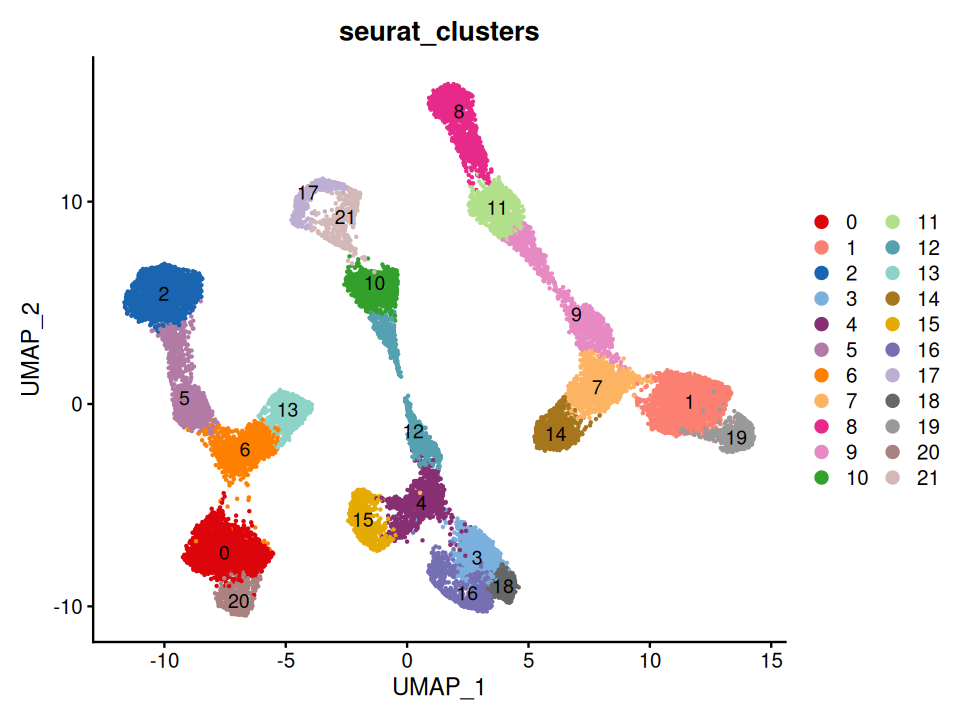

In [80]:
options(repr.plot.width =8, repr.plot.height=6)

DimPlot(seurat_sim,reduction = "umap",group.by = c('seurat_clusters'),label = T,raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))


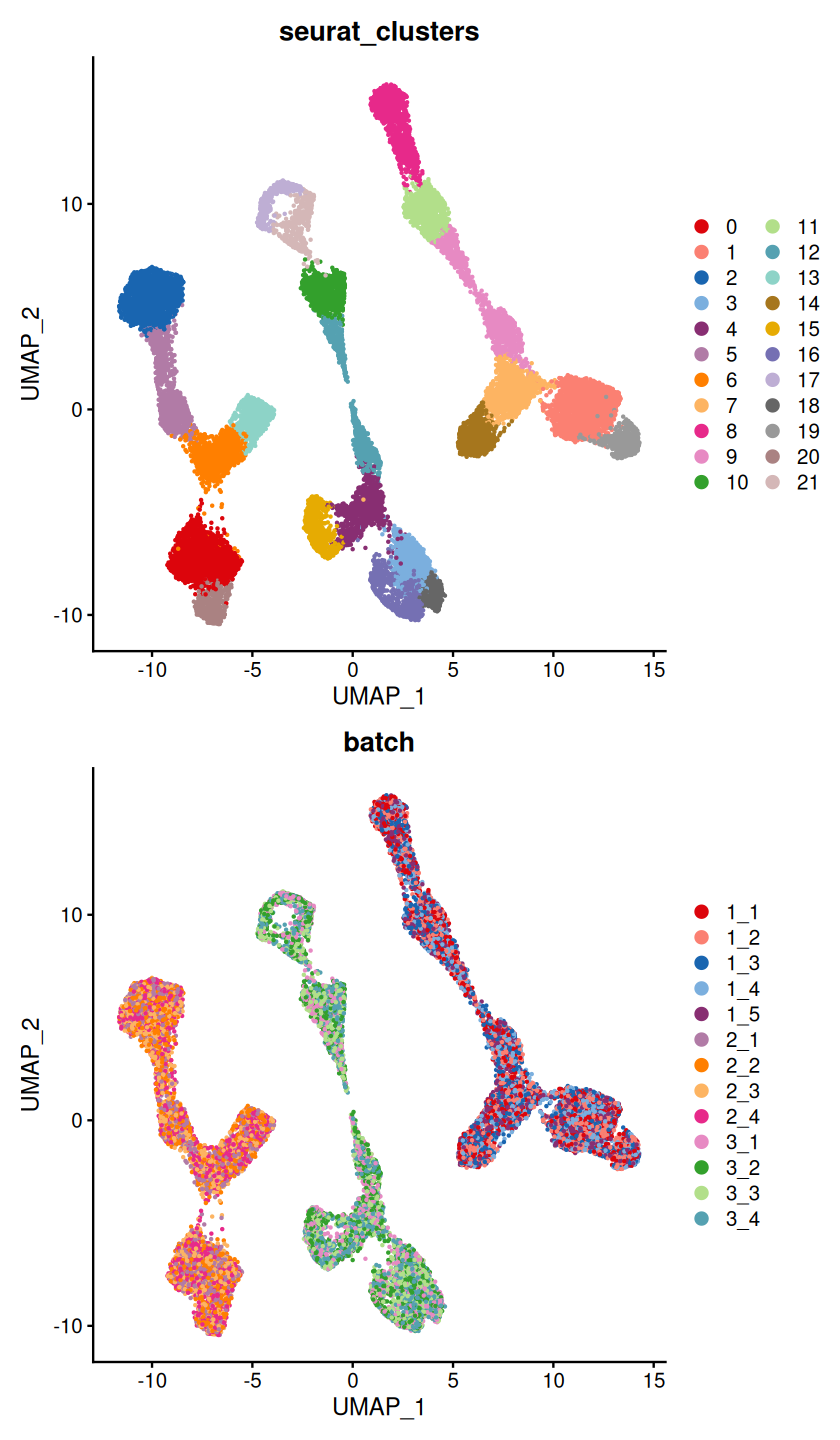

In [82]:
options(repr.plot.width =7, repr.plot.height=12)

DimPlot(seurat_sim,reduction = "umap",group.by = c("seurat_clusters","batch"),raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))

In [84]:
saveRDS(seurat_sim ,'./04_seurat_sim.rds')